# Prior
- database for gene co-expression: https://coxpresdb.jp/gene_coexpression/?gene_id=7535&dataset=17
- topic modeling: https://github.com/gregversteeg/corex_topic/blob/master/corextopic/example/corex_topic_example.ipynb 

1.	PI3K/AKT/mTOR: Increase
2.	mTORC1: Increase
3.	P53: Increase
4.	TNF-α/NF-κB: Increase
5.	TGF-β: Increase
6.	WNT/β-Catenin: Dysregulated
7.	Oxidative Phosphorylation (OXPHOS): Decrease


# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx
from scipy.stats import zscore
import sys
import matplotlib.pyplot as plt
import scanpy as sc 
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests
from matplotlib.gridspec import GridSpec



from src.helper import get_genesets, get_gene2pathway, surrogate_names
from src.helper_diff_analys import infer_grn, determine_centrality_all

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from grn_benchmark.src.helper import surragate_names, plot_heatmap

from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt
from scipy.cluster.hierarchy import linkage

from src.helper_diff_analys import consistency_metrics, plot_gene_centrality_vs_expression

%matplotlib inline
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'
results_folder = 'output/'

os.makedirs(results_folder, exist_ok=True)


genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

pathway_df = get_gene2pathway()

# major_celltypes = ['B cells',
#        'CD4+ T cells', 'MAIT cells', 'Myeloid cells', 'NK cells',
#         'TRAV1-2- CD8+ T cells']
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/prior/tf_all.csv', dtype=str)

# df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
# housekeeping_genes = set(df.loc[:, 0])

In [119]:
if False:
    file_path = 'input/akshayata_pathways.xlsx'
    sheets = pd.read_excel(file_path, sheet_name=None)
    dataframes = {sheet_name: data for sheet_name, data in sheets.items()}
    df_store = []
    for sheet_name, df in dataframes.items():
        df_store.append(df)

    df = pd.concat(df_store)
    genesets_all = {pathway:genes.split(',') for pathway, genes in zip(df['term description'], df['gene_sym'])}

    # Create a list of gene-to-pathway mappings (one-to-one mapping)
    gene_to_pathway_list = [
        (gene, pathway)
        for pathway, genes in genesets_all.items()
        for gene in genes
    ]

    # Convert the list to a DataFrame
    df_pathway = pd.DataFrame(gene_to_pathway_list, columns=["gene", "pathway"])
    df_pathway = df_pathway.set_index("gene")
    df_pathway['pathway'] = df_pathway['pathway'].str.replace('HALLMARK_','')

    df_pathway
else: # canonical
    geneset_file = 'input/prior/h.all.v2024.1.Hs.symbols.gmt'
    genesets_all = read_gmt(geneset_file) 
    genesets_all = {key: gs['genes'] for key, gs in genesets_all.items()}

    # Create a list of gene-to-pathway mappings (one-to-one mapping)
    gene_to_pathway_list = [
        (gene, pathway)
        for pathway, genes in genesets_all.items()
        for gene in genes
    ]

    # Convert the list to a DataFrame
    df_pathway = pd.DataFrame(gene_to_pathway_list, columns=["gene", "pathway"])
    df_pathway = df_pathway.set_index("gene")
    df_pathway['pathway'] = df_pathway['pathway'].str.replace('HALLMARK_','')
    df_pathway['pathway'] = df_pathway['pathway'].str.replace('_',' ')
    df_pathway['pathway'] = df_pathway['pathway'].str.title()

    df_pathway

# Infer GRNs

In [4]:
if False:
    from src.helper_diff_analys import infer_grns_all
    infer_grns_all()

In [5]:
# def safe_zscore(series):
#     if series.std() == 0:
#         return np.zeros(len(series))  # Assign 0 z-scores if no variation
#     else:
#         return zscore(series)

In [3]:
# - collect individual grns 
if True:
    net_store = []
    for dataset in ['data1', 'pbmc_ageing']:
        par = {
                'cell_types' : ['CD4+ T cells','CD8+ T cells', 'Myeloid cells', 'B cells','NK cells'],
                'age_groups': ['34-','35_44','45_54','55_64','65_75'],
                'batches': ['batch_1', 'batch_2', 'all_batches'],
                'read_dir': f'output/grns/{dataset}',
                'net_all': 'output/grns/net_all.csv'
            }
        for cell_type in par['cell_types']:
            for age_group in par['age_groups']: # only age groups for -1 cell type
                for batch_group in par['batches']:
                    save_file_name = os.path.abspath(f"{par['read_dir']}/net_{cell_type}_{age_group}_{batch_group}.csv")
                    net = pd.read_csv(save_file_name, index_col=0)
                    net['cell_type'] = cell_type
                    net['age_group'] = age_group
                    net['batch_group'] = batch_group
                    net['dataset'] = dataset
                    
                    # net = net.sort_values('weight', key=abs, ascending=False)[:200_000]

                    net['zscore'] = zscore(net['weight'])
                    assert not net['zscore'].isna().any()

                    net_store.append(net)
    
    net_all = pd.concat(net_store)         
    net_all.to_csv(par['net_all'])
else:
    net_all = pd.read_csv(par['net_all'], index_col=0)

if True: # only selected pathways
    print(net_all.shape)
    mask = net_all['source'].isin(target_genes) & net_all['target'].isin(target_genes)
    net_all = net_all[mask]
    print(net_all.shape)

(34870060, 8)
(985417, 8)


## Explanatory analysis

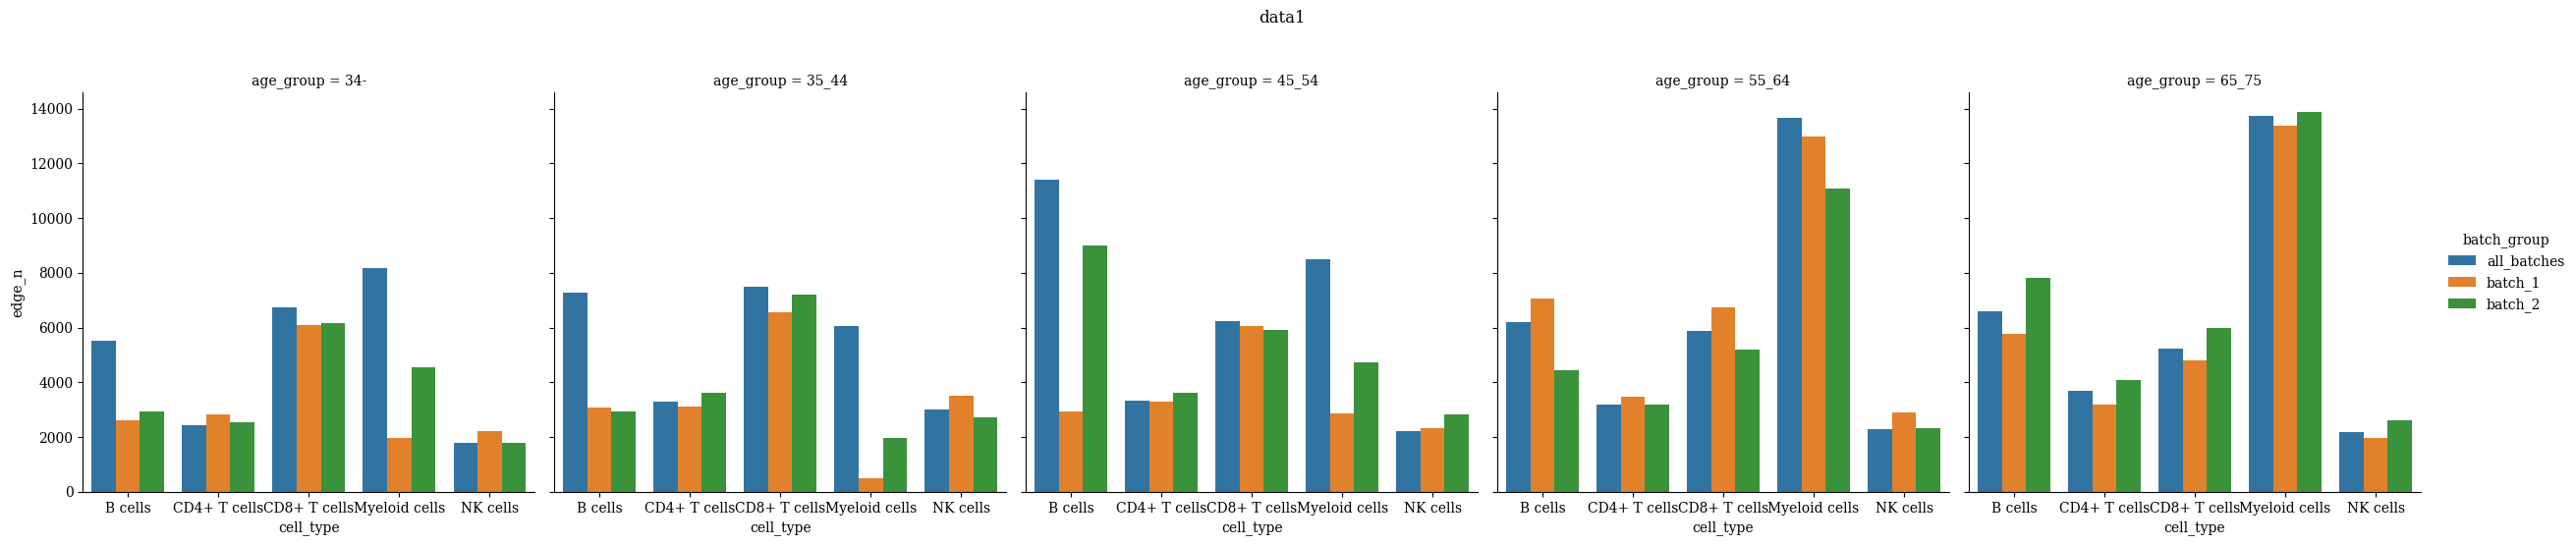

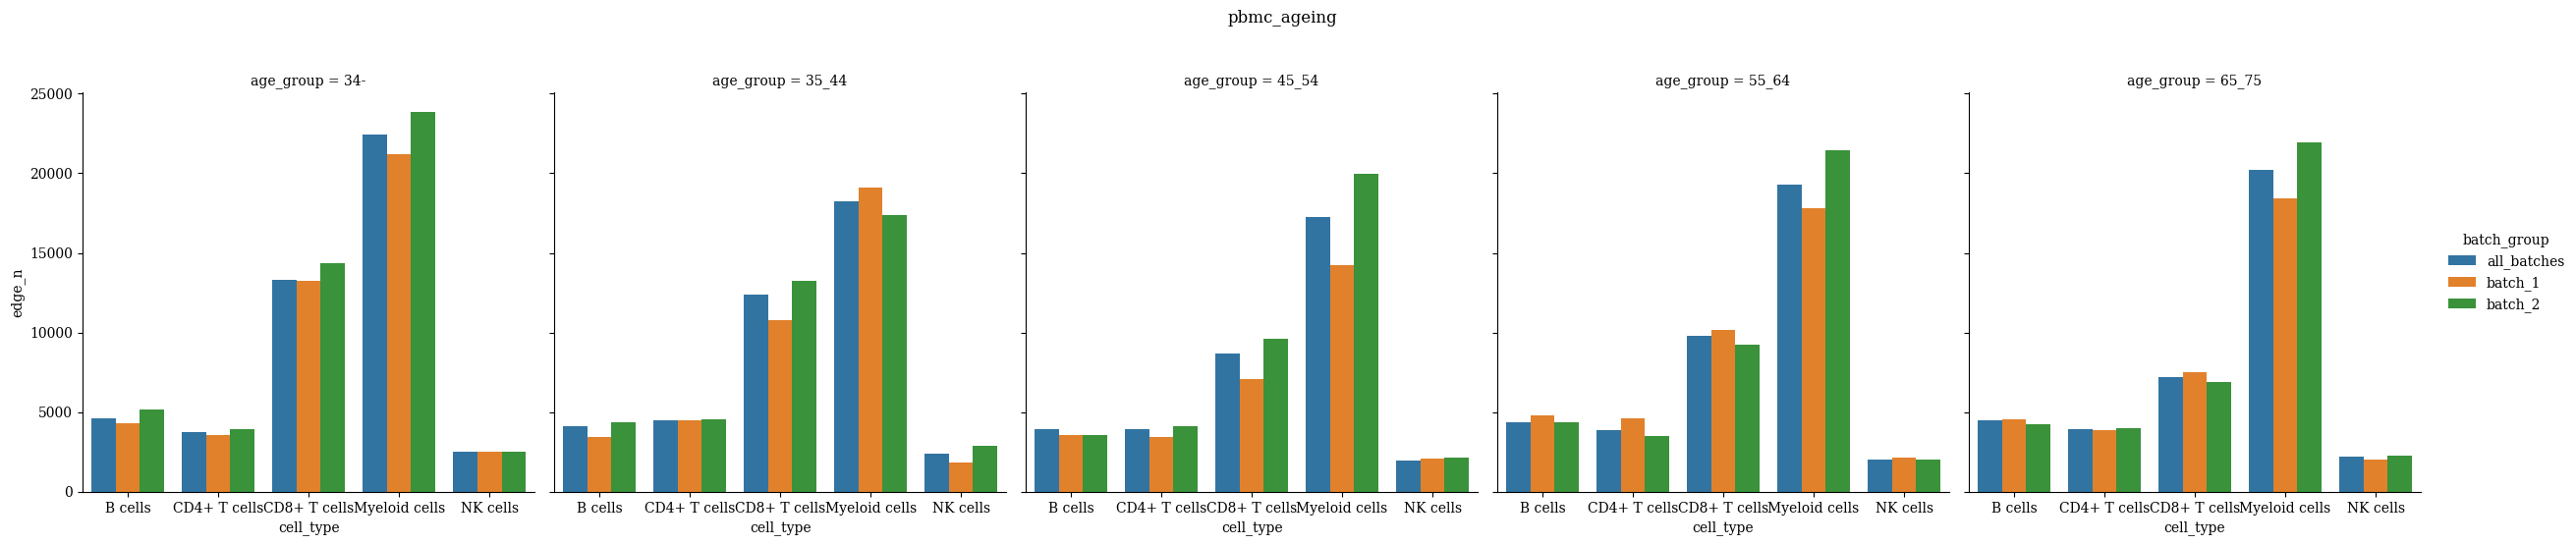

In [5]:
for dataset in net_all['dataset'].unique():
    net_dataset = net_all[net_all['dataset']==dataset]
    groups = net_dataset.groupby(['cell_type', 'age_group', 'batch_group'])
    edges_n = groups.size().reset_index(name='edge_n')
    source_n = groups['source'].nunique().reset_index(name='source_n')
    target_n = groups['target'].nunique().reset_index(name='target_n')
    sns.catplot(edges_n, x='cell_type', y='edge_n', col='age_group', hue='batch_group', kind='bar')
    plt.suptitle(dataset, y=1.1)

In [71]:
if False: #cumulative density
    for cell_type in net_all['cell_type'].unique():
        mask_celltype = net_all['cell_type']==cell_type
        fig, axes = plt.subplots(1, 5, figsize=(12, 3), sharey=True)
        for i, age_group in enumerate(net_all['age_group'].unique()):
            mask_age = net_all['age_group']==age_group

            ax = axes[i]
            for batch in net_all['batch_group'].unique():
                mask_batch = net_all['batch_group'] == batch
                # ax.hist(net_all[mask_age&mask_celltype&mask_batch]['weight'].values, label=batch, bins=100)
                plot_cumulative_density(net_all[mask_age&mask_celltype&mask_batch]['weight'].values, label=batch, ax=ax)
            ax.set_title(age_group)
        ax.legend(loc=(1.05, .2))
        plt.tight_layout()
        plt.suptitle(cell_type, y=1.2)

In [6]:
net_all = net_all.drop('weight', axis=1).rename({'zscore':'weight'}, axis=1)

## Compare hub genes between individual batch GRNs and the combined: evaluate batch effect

In [73]:
if False: # compare the hub genes obtained for the whole age group with batch specific hub genes
    from src.helper_diff_analys import evaluate_batch_effect_on_hub_genes
    recall_list = evaluate_batch_effect_on_hub_genes()
# (88,)
# (88,)
# (72,)
# (75,)
# (84,)

## Check consistency between two batch groups

In [74]:
if True: # check consistenct in centrality between two batches, straified by age group and cell type
    from src.helper_diff_analys import determine_centrality_consistency
    centrality_consistency_scores = determine_centrality_consistency(net_all)
    centrality_consistency_scores.to_csv('output/centrality_consistency_scores.csv')


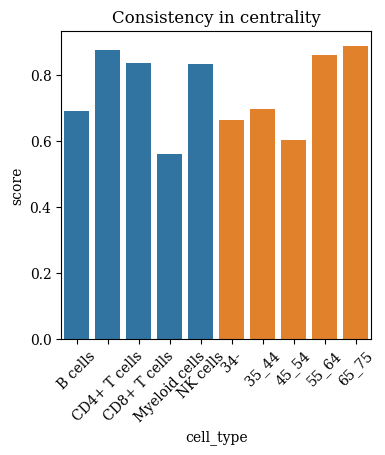

In [75]:
centrality_consistency_scores = pd.read_csv('output/centrality_consistency_scores.csv')
for seg in ['cell_type', 'age_group']:
    scores_all_sub = centrality_consistency_scores[~centrality_consistency_scores[seg].isna()].reset_index(drop=True)
    ax = sns.barplot(data=scores_all_sub, x=seg, y='score')
    ax.tick_params(axis='x', rotation=45)  # Correct rotation for x-axis labels
    ax.set_title(f'Consistency in centrality')

# Centrality analysis

In [7]:
from src.helper_diff_analys import plot_joint_centrality_wrapper, find_consistency_between_batches, get_metadata, plot_joint_centrality_heatmap, plot_centrality_heatmap_metadata
from src.helper import surrogate_names

In [9]:
# - calculate centrality
centrality_all = determine_centrality_all(net_all, use_weight=True)
# centrality_all = centrality_all[centrality_all['batch_group'].isin(['batch_1','batch_2'])]
centrality_all['is_tf'] = centrality_all['gene'].isin(tf_all)
centrality_all['batch_group'].unique()

array(['all_batches', 'batch_1', 'batch_2'], dtype=object)

In [78]:
if False:
    # - calculate diff centrality
    from src.helper_diff_analys import determine_diff_centrality_all, filter_noisy_genes
    def determine_diff_centrality_all(centrality_df):
        diff_centrality_all = []

        batch_groups = centrality_df.batch_group.unique()
        cell_types = centrality_df.cell_type.unique()
        age_groups = centrality_df.age_group.unique()

        for batch_group in batch_groups:
            for cell_type in cell_types:
                mask = (centrality_df.cell_type==cell_type)&(centrality_df.batch_group==batch_group)
                centrality_sub = centrality_df[mask]
                df_ref = centrality_sub[centrality_sub.age_group=='34-'][['gene','centrality']].set_index('gene')
                for age_group in age_groups:
                    if age_group == '34-':
                        continue
                    df_sample = centrality_sub[centrality_sub.age_group==age_group][['gene','centrality']].set_index('gene')
                    df_merged = df_sample.merge(df_ref, left_index=True, right_index=True, suffixes=['_sample','_ref'], how='outer').fillna(0)

                    # - main
                    pseudocount = 1e-6
                    c_ref = df_merged['centrality_ref'] + pseudocount
                    c_sample = df_merged['centrality_sample'] + pseudocount
                    df_merged['diff'] = c_sample-c_ref
                    df_merged['fold_change'] = np.where(
                        c_sample > c_ref,
                        c_sample / c_ref,
                        c_ref / c_sample
                    )
                    df_merged['signed_fold_change'] = np.sign(df_merged['diff'])*df_merged['fold_change']
                    df_merged['log2_fold_change'] = np.log2(df_merged['fold_change'])
                    df_merged['signed_log2_fold_change'] = np.sign(df_merged['diff'])*df_merged['log2_fold_change']
                    

                    df_merged['batch_group'] = batch_group
                    df_merged['cell_type'] = cell_type
                    df_merged['age_group'] = age_group

                    diff_centrality_all.append(df_merged)

        diff_centrality_all = pd.concat(diff_centrality_all)

        
        return diff_centrality_all
    diff_centrality_all = determine_diff_centrality_all(centrality_all).reset_index()
    diff_centrality_all = filter_noisy_genes(diff_centrality_all)

    diff_centrality_all['is_tf'] = diff_centrality_all['gene'].isin(tf_all)
    diff_centrality_all.sort_values('fold_change', key=abs)[::-1].head(5)

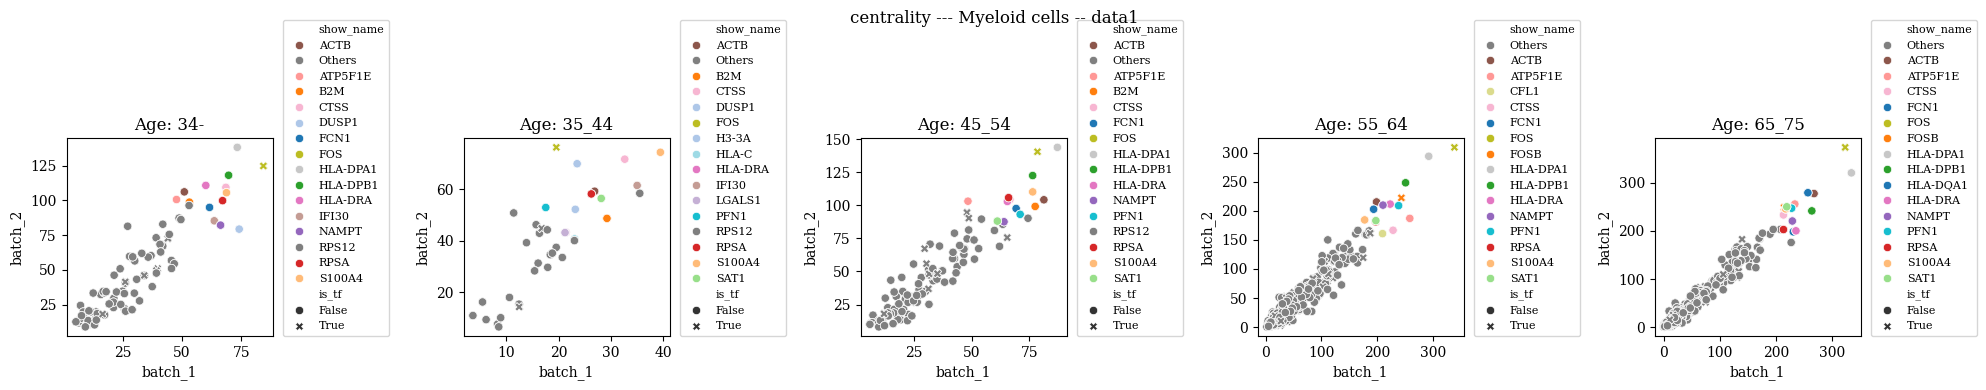

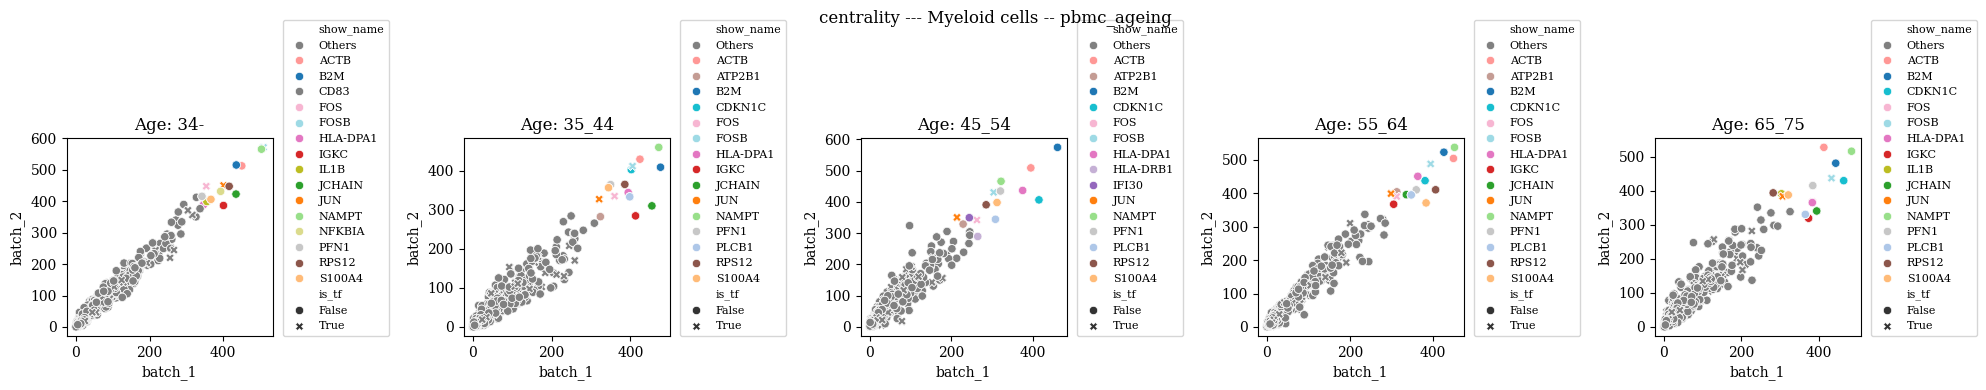

In [10]:
cell_type='Myeloid cells'
top_n_genes = 15

for dataset in centrality_all['dataset'].unique():
    centrality_dataset = centrality_all[centrality_all['dataset']==dataset] 

    centrality_df = centrality_dataset.groupby('cell_type').get_group((cell_type))
    # diff_centrality_df = diff_centrality_all.groupby('cell_type').get_group((cell_type))

    _ = plot_joint_centrality_wrapper(centrality_df.copy(), key_value='centrality', top_n_genes=top_n_genes, title=f'centrality --- {cell_type} -- {dataset}')
    # __ = plot_joint_centrality_wrapper(diff_centrality_df, key_value='diff', top_n_genes=top_n_genes, title=f'Diff centrality --- {cell_type}')
    # __ = plot_joint_centrality_wrapper(diff_centrality_df, key_value='signed_log2_fold_change', top_n_genes=top_n_genes, title=f'signed_log2_fold_change --- {cell_type}')

In [37]:
n_top = 50
ref_dataset = 'pbmc_ageing'
ref_batch = 'all_batches'

centrality_ref = centrality_all[centrality_all['dataset']==ref_dataset] 
centrality_ref = centrality_ref.groupby('cell_type').get_group((cell_type))
# - select the top genes across different age groups
top_genes = centrality_ref[centrality_ref['batch_group']==ref_batch].groupby('age_group').apply(lambda df: df.loc[df['centrality'].abs().nlargest(n_top).index])['gene'].unique()
print('number of top genes: ', len(top_genes))

# - subset to top genes
centrality_top = centrality_all[centrality_all['gene'].isin(top_genes)] 
centrality_sub = centrality_top.groupby('cell_type').get_group((cell_type))

# - subset to most variable genes
top_quantile = .5 #top 
df_pivot = centrality_sub[(centrality_sub['batch_group']==ref_batch)&(centrality_sub['dataset']==ref_dataset)].pivot(index='gene', columns='age_group', values='centrality')
norm_std = df_pivot.std(axis=1)/df_pivot.mean(axis=1)
top_variable_genes = df_pivot[norm_std>norm_std.quantile(top_quantile)].index.values

centrality_sub = centrality_sub[(centrality_sub['gene'].isin(top_variable_genes))]

# - make the names pretier
centrality_sub['centrality'] = centrality_sub['centrality'].rank()
centrality_sub



number of top genes:  68


,gene,centrality,cell_type,batch_group,age_group,dataset,is_tf
14,NR4A2,68.0,Myeloid cells,all_batches,34-,data1,True
22,CCNL1,109.0,Myeloid cells,all_batches,34-,data1,False
33,HLA-C,252.0,Myeloid cells,all_batches,34-,data1,False
34,HLA-B,224.0,Myeloid cells,all_batches,34-,data1,False
53,KLF6,171.0,Myeloid cells,all_batches,34-,data1,True
...,...,...,...,...,...,...,...
184,SAT1,617.0,Myeloid cells,batch_2,65_75,pbmc_ageing,False
261,IRF4,470.0,Myeloid cells,batch_2,65_75,pbmc_ageing,True
294,HSP90B1,287.0,Myeloid cells,batch_2,65_75,pbmc_ageing,False
308,TRAF4,553.0,Myeloid cells,batch_2,65_75,pbmc_ageing,True


In [ ]:
# centrality_plot = centrality_sub.copy()
# centrality_plot['batch_group'] = centrality_plot['batch_group'].apply(lambda name: surrogate_names.get(name,name))
# centrality_plot['age_group'] = centrality_plot['age_group'].apply(lambda name: surrogate_names.get(name,name))
# plot_joint_centrality_heatmap(centrality_plot, title=f'Centrality dynamics ({cell_type})', length=5, width=3, cluster_offset=-.02, ref_batch=ref_batch)


Text(1, 0.9, 'Centrality dynamics (Myeloid cells)')

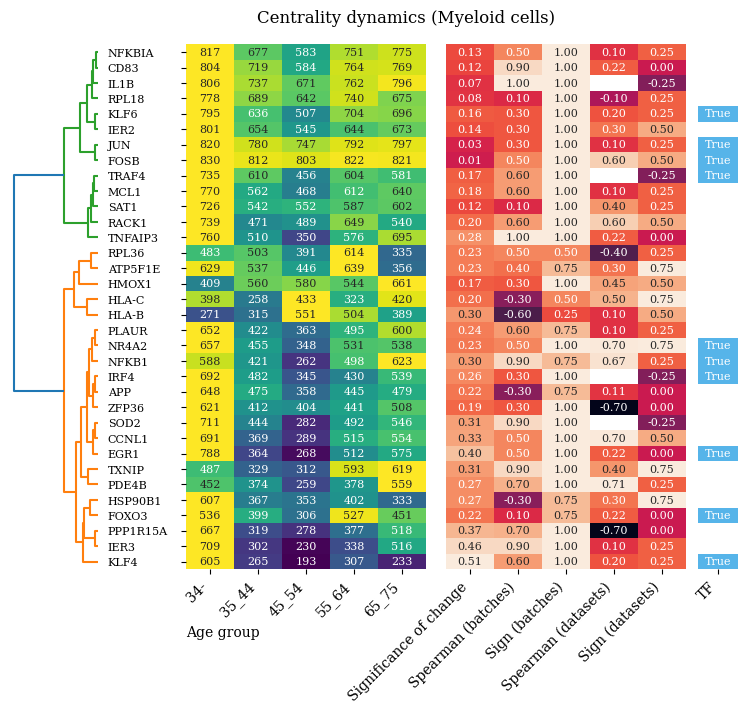

In [139]:
from src.helper_diff_analys import get_metadata
metadata = get_metadata(centrality_sub, tf_all=tf_all, ref_dataset='pbmc_ageing', val_dataset='data1')
plot_centrality_heatmap_metadata(centrality_sub[(centrality_sub['batch_group']=='all_batches')&(centrality_sub['dataset']=='pbmc_ageing')], metadata, length=7, width=4, cluster_offset=-.15)
plt.suptitle(f'Centrality dynamics ({cell_type})', y=.9, x=1)

# Pathway analysis

In [168]:
# - assign pathways to source and target
pathway_genes = df_pathway.index.unique().values
net_all_annotated = net_all[net_all['source'].isin(pathway_genes)&net_all['target'].isin(pathway_genes)]

net_all_annotated = net_all_annotated.merge(df_pathway.reset_index().rename(columns={'gene':'source', 'pathway':'pathway_source'}),
                                 on='source')
net_all_annotated = net_all_annotated.merge(df_pathway.reset_index().rename(columns={'gene':'target', 'pathway':'pathway_target'}),
                                 on='target')
                                
# - take the abs sum of weight to calculate weight for pathways  #TODO: normalize to the the count of pathways
net_all_pathways = net_all_annotated.groupby(['cell_type', 'age_group', 'batch_group', 'dataset', 'pathway_source', 'pathway_target'])['weight'].apply(lambda x: x.abs().sum()).reset_index()

net_all_pathways['pathway_combination'] = net_all_pathways.apply(
        lambda row: '-'.join(sorted([row['pathway_source'], row['pathway_target']])),
        axis=1
    )
net_all_pathways = net_all_pathways.groupby(['cell_type', 'age_group', 'batch_group', 'dataset', 'pathway_combination'], as_index=False).agg({'weight': 'sum'})


In [166]:
net_pathways = net_all_pathways.groupby('cell_type').get_group((cell_type))
net_pathways['is_tf']=False

# - select the top pathways from each age groups
n_top = 30
net_pathways_ref = net_pathways[net_pathways['dataset']==ref_dataset]
top_pathways = net_pathways_ref[net_pathways_ref['batch_group']=='all_batches'].groupby('age_group').apply(lambda df: df.loc[df['weight'].abs().nlargest(n_top).index])['pathway_combination'].unique()
print('number of top genes: ', len(top_pathways))
net_pathways = net_pathways[(net_pathways['pathway_combination'].isin(top_pathways))]

# - subset to most variable genes
top_quantile = .3 #top 
df_pivot = net_pathways_ref[net_pathways_ref['batch_group']=='all_batches'].pivot(index='pathway_combination', columns='age_group', values='weight')
norm_std = df_pivot.std(axis=1)/df_pivot.mean(axis=1)
top_variable_pathways = df_pivot[norm_std>norm_std.quantile(top_quantile)].index.values

net_pathways = net_pathways[(net_pathways['pathway_combination'].isin(top_variable_pathways))]

net_pathways['weight'] = net_pathways['weight'].rank()


number of top genes:  34


Text(2, 0.9, 'Pathway interaction dynamics (Myeloid cells)')

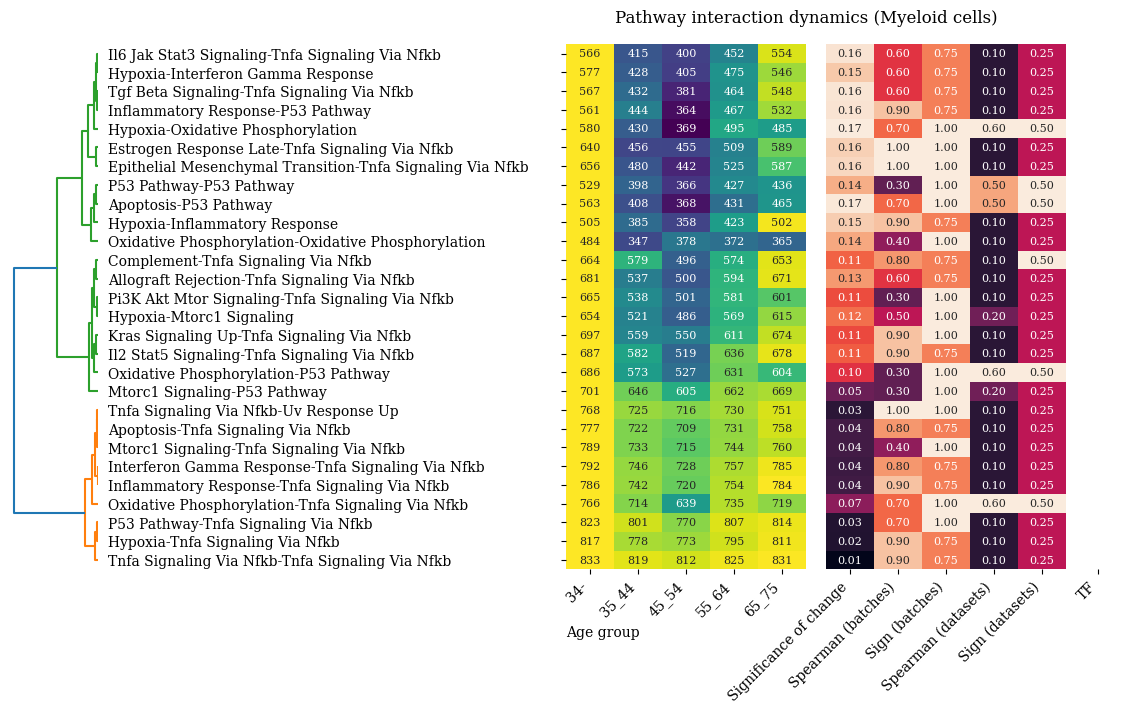

In [184]:
metadata = get_metadata(net_pathways.rename(columns={'pathway_combination':'gene', 'weight':'centrality'}), tf_all=tf_all, ref_dataset='pbmc_ageing', val_dataset='data1')
plot_centrality_heatmap_metadata(net_pathways[(net_pathways['batch_group']=='all_batches')&(net_pathways['dataset']=='pbmc_ageing')].rename(columns={'pathway_combination':'gene', 'weight':'centrality'})
                                , metadata, length=7, width=4, cluster_offset=.8)
plt.suptitle(f'Pathway interaction dynamics ({cell_type})', y=.9, x=2)

In [84]:
aaa

NameError: name 'aaa' is not defined

# infer GRNs for top donors -> batch effect free

In [118]:
from src.helper import major_cell_types

In [54]:
if False: # infer GRNs for top donors -> batch effect free
    # def infer_grns_all_donors(input_file= 'input/dataset_1_2.h5ad'):
    input_file= 'input/dataset_12_equalized_donors.h5ad'
    par = {
            'dataset_file':input_file,
            'save_dir': f'output/grns/',
            'min_cells_per_gene': 500,
            'weight_t': .05,
            'sample_t': 5000
        }
    # - dependencies
    adata = ad.read_h5ad(par['dataset_file'])
    # - fix the granualariy of the cell typs based on geneRNIB
    obs = adata.obs.copy()


    # - infer grns for top donors
    i_exp = 0
    for i_cell_type, cell_type in enumerate(major_cell_types):
        cell_type_mask = (obs['cell_type'] == cell_type)   
        
        for age_group in list(obs['age_group'].unique()): 
            age_group_mask = (obs['age_group'] == age_group)
        
            mask_sample = age_group_mask & cell_type_mask
            donors = obs.loc[mask_sample, 'donor_id']
            unique_donors = donors.unique()
            # print(cell_type, age_group, unique_donors.shape)
            for donor_id in unique_donors:
                mask_donor = obs.loc[mask_sample, 'donor_id'] == donor_id
                
                if mask_donor.sum()<par['sample_t']:
                    continue
                else:
                    print(cell_type, age_group, donor_id, mask_sample.sum(), mask_donor.sum())
            

# Joint analysis of differential genes and centrality

## Diff genes

In [136]:
if False:
    from src.helper_diff_analys import run_DEA
    run_DEA() # set the settigs inside, 

## Centrality vs DE for different cell types

In [137]:
def retrieve_dea_rr(file_name):
    # - retrieve the DE genes results
    de_results = pd.read_csv(file_name)

    de_results['fold_change'] = (de_results['mean_test']+1E-6)/(de_results['mean_ref']+1E-6)
    de_results['log_fold_change'] = np.log10(de_results['fold_change'])
    de_results['p_value_adj'] = de_results['p_value']*len(de_results)
    de_results.loc[de_results['p_value_adj'] > 1, 'p_value_adj'] = 1
    de_results['-log10_pvalue'] = -np.log10(de_results['p_value'])

    de_results['-fc_log10_pvalue'] = -de_results['log_fold_change']*np.log10(de_results['p_value'])
    de_results.sort_values('p_value_adj')
    return de_results
de_results = retrieve_dea_rr(f'output/diff_genes/de_genes_dataset1_2.csv')

Text(0.5, 1.1, 'T cells')

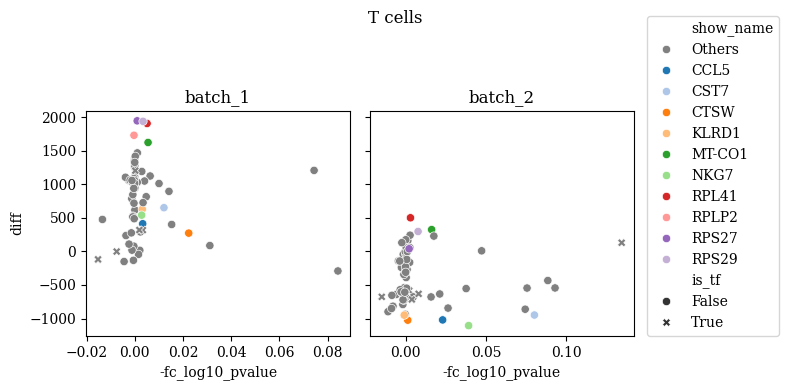

In [138]:
def merge_de_with_dc_results(diff_centrality_all, de_results, age_group, cell_type, tf_all, hub_genes_n=10):
    # - subset the dr results
    c_sub = diff_centrality_all.groupby(['age_group', 'cell_type']).get_group((age_group, cell_type))
    c_genes = c_sub['gene'].unique()

    # - subset the de results
    de_sub = de_results.groupby(['age_group', 'cell_type']).get_group((age_group, cell_type))
    de_sub = de_sub[de_sub['gene'].isin(c_genes)]

    #- merge
    df_merged = c_sub.merge(de_sub, on=['gene', 'batch_group'])
    
    highly_diff_genes = (
        df_merged
        .assign(abs_diff=lambda df: df['diff'].abs())  # Create a temporary column with absolute values
        .groupby('batch_group', group_keys=False)  # Group by 'batch_group'
        .apply(lambda df: df[df['abs_diff'] >= df['abs_diff'].quantile(0.99)]['gene'])
        .values.flatten()
    )
    df_merged = df_merged[df_merged['gene'].isin(highly_diff_genes)]
    
    hub_genes = (
        df_merged
        .assign(abs_diff=lambda df: df['diff'].abs())  # Create a temporary column with absolute values
        .groupby('batch_group')
        .apply(lambda df: df.nlargest(hub_genes_n, 'abs_diff')['gene'])
        .values.flatten()
    )
    df_merged['is_hub_gene'] = df_merged['gene'].isin(hub_genes)
    # - tf 
    df_merged['is_tf'] = df_merged['gene'].isin(tf_all)

    return df_merged
age_group = '65_75'
cell_type = 'T cells' #'Myeloid cells'


rr_merged = merge_de_with_dc_results(diff_centrality_all, de_results, age_group, cell_type, tf_all=tf_all, hub_genes_n=5)

plot_gene_centrality_vs_expression(rr_merged)
plt.suptitle(cell_type, y=1.1)

## Dynamic of pathway interaction in the course of age

In [139]:
rr_all = consistency_metrics(f'output/diff_corr/net_all_{dataset}.csv')

NameError: name 'dataset' is not defined

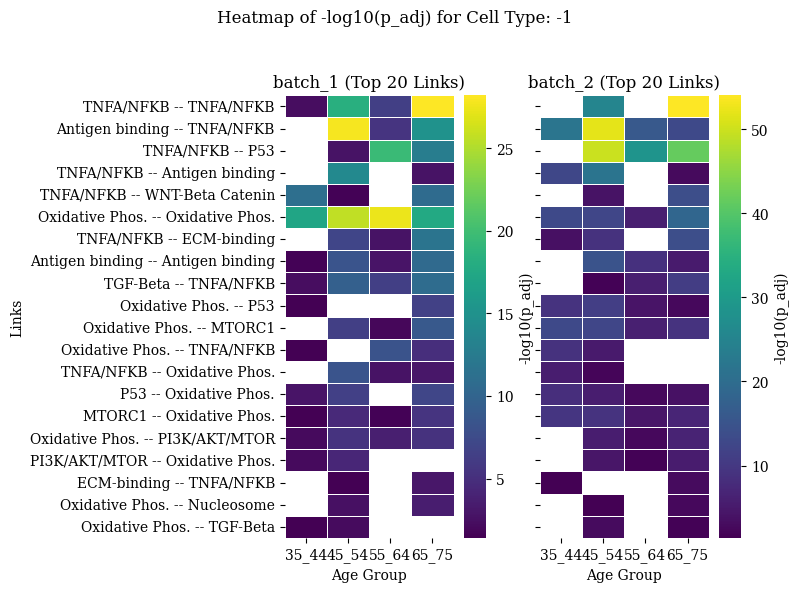

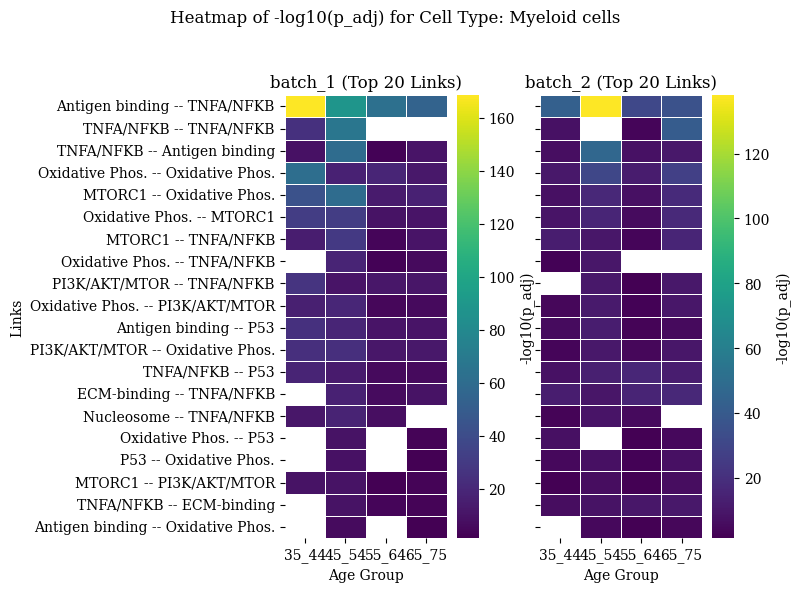

In [29]:
if True:
    from src.helper_plots import plot_pathway_change_age
    filtered_interaction_score_all = rr_all['filtered_interaction_score_all']
    for cell_type in ['-1','Myeloid cells']:
        plot_pathway_change_age(filtered_interaction_score_all, cell_type)

# Diff correlation: explanatory analysis

In [36]:
# - define target genes 
if True:
    genesets = get_genesets()
    target_genes = np.unique(np.concatenate(list(genesets.values())))
net_all = retrieve_dca_rr('output/diff_corr/net_all_dataset1_2.csv')
net_all_sig = dc_results[dc_results['sig']]

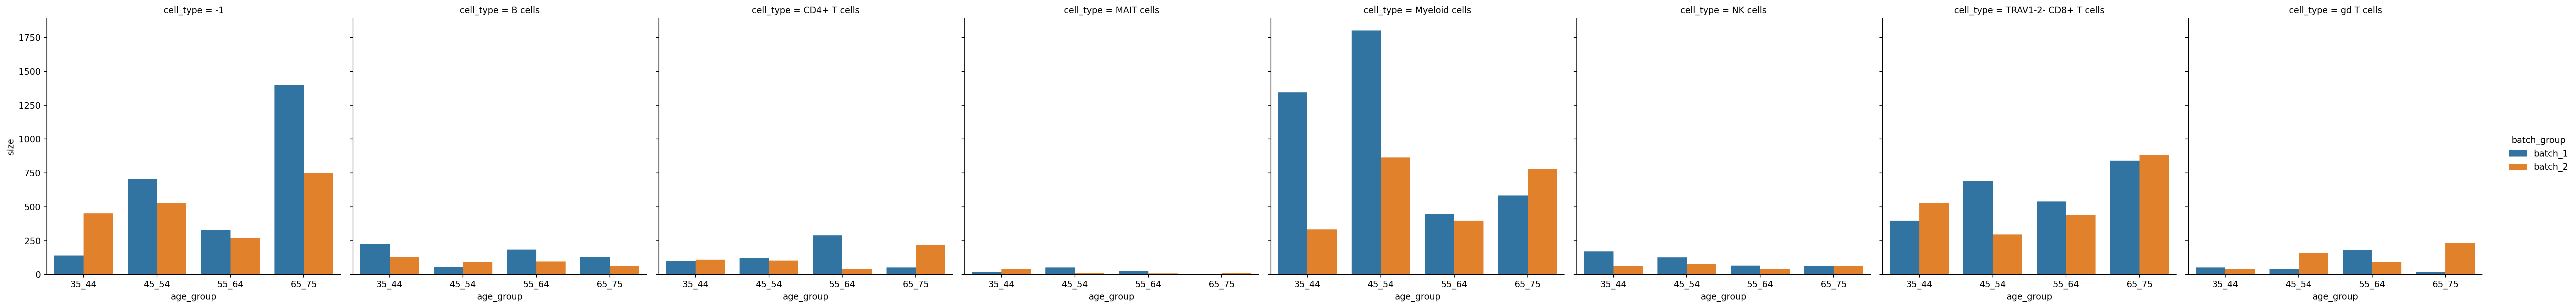

In [37]:
# - overview of sig links distrbutionn
groups = net_all_sig.groupby(['cell_type', 'age_group'])
n_sig_links = net_all_sig.groupby(['cell_type','age_group','batch_group']).size().reset_index(name='size')
sns.catplot(n_sig_links, x='age_group', y='size', hue='batch_group', col='cell_type', kind='bar')

def plot_joint_diff_links(df_long, key1, key2):
    df_table = df_long.pivot(index='link', columns='batch_group', values='diff')


    mask_na = ~df_table.isna()
    df_table['sig'] = 'None'
    df_table.loc[mask_na[key1], 'sig'] = key1
    df_table.loc[mask_na[key2], 'sig'] = key2
    df_table.loc[mask_na[key1] & mask_na[key2], 'sig'] = 'Both'

    print(df_table.shape)

    df_table.fillna(0, inplace=True)

    for name in ['None', key1, key2, 'Both']:
        mask = df_table['sig'] == name
        n = (mask).sum()
        df_table.loc[mask, 'sig'] += f' ({n})'


    sns.jointplot(
            data = df_table, 
            x = key1, 
            y = key2, 
            hue= 'sig',   # Color points by "True"/"False"
            # markers=True,
            # kind="kde",    # Contours with kde
            # fill=False,    # Fill contour lines
            marginal_kws=dict(common_norm=False, fill=True),  # Marginal distribution,
            alpha=.5,
            height=3,

        )
    plt.legend(loc=(1.2, .5))
df_long = groups.get_group(('-1','65_75'))

In [38]:
if False:
    net_all.groupby(['age_group', 'cell_type']).apply(lambda df: np.unique(df[['g1', 'g2']].values.flatten()).shape[0])

(1955, 3)


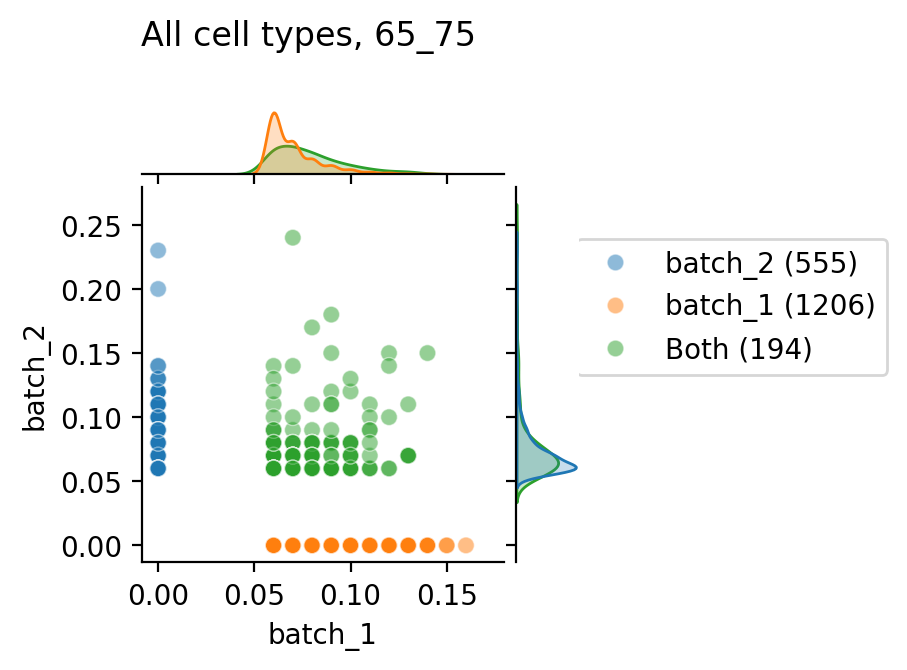

In [39]:
# initial overview
net_all_sig = net_all_sig


batch_keys = df_long['batch_group'].unique()
if len(batch_keys) > 1:
    plot_joint_diff_links(df_long, key1=batch_keys[0], key2=batch_keys[1])
    plt.suptitle('All cell types, 65_75', y=1.1)

In [40]:
# - probibility of overlap under null hypothesis
from scipy.stats import poisson

group1_sig = net_all[(net_all['batch_group'] == 'batch_1') & net_all['sig']]['link']
group2_sig = net_all[(net_all['batch_group'] == 'batch_2') & net_all['sig']]['link']

overlap = len(set(group1_sig) & set(group2_sig))
N = len(net_all)
S1 = len(group1_sig)
S2 = len(group2_sig)
print(S1, S2, N, overlap)


lambda_expected = S1 * S2 / N
n = overlap  # Number of observed overlaps
prob = poisson.pmf(n, lambda_expected)
prob

11170 8203 9973051 2433


0.0

In [41]:
# - probibility of overlap under null hypothesis
def confidence_func(df):
    group1_sig = df[(df['batch_group'] == 'batch_1') & df['sig']]['link']
    group2_sig = df[(df['batch_group'] == 'batch_2') & df['sig']]['link']

    overlap = len(set(group1_sig) & set(group2_sig))
    N = len(net_all)
    S1 = len(group1_sig)
    S2 = len(group2_sig)
    # print(S1, S2, N, overlap)


    lambda_expected = S1 * S2 / N
    n = overlap  # Number of observed overlaps
    prob = 1 - poisson.cdf(n, lambda_expected)
    return prob

confidence_pvalue = net_all.groupby(['age_group','cell_type']).apply(confidence_func).reset_index(name='pvalue')
mat_pvalues = confidence_pvalue.pivot(index='age_group', columns='cell_type', values='pvalue')

mat_pvalues

cell_type,-1,B cells,CD4+ T cells,MAIT cells,Myeloid cells,NK cells,TRAV1-2- CD8+ T cells,gd T cells
age_group,,,,,,,,
35_44,0.0,0.0,0.0,6.328271e-14,0.0,5.402197e-07,0.0,0.000000e+00
45_54,0.0,0.0,0.0,2.364775e-14,0.0,0.000000e+00,0.0,0.000000e+00
55_64,0.0,0.0,0.0,1.925170e-05,0.0,3.680366e-08,0.0,0.000000e+00
65_75,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,1.207490e-11


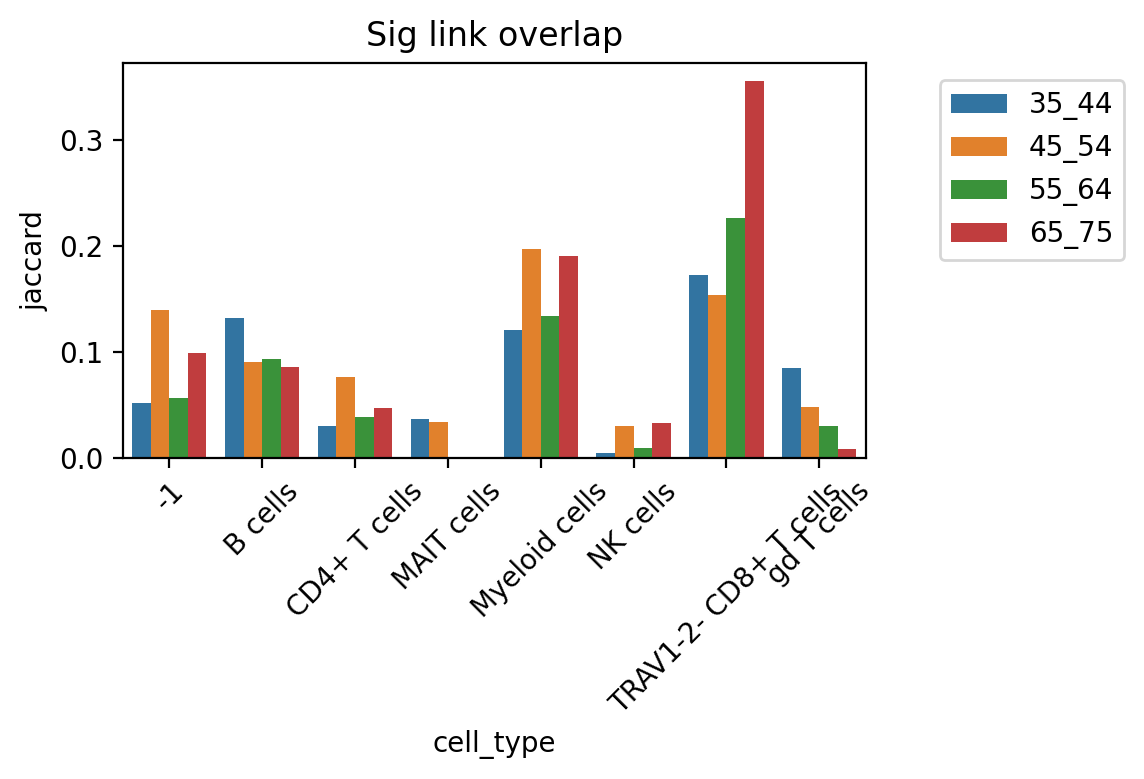

In [42]:
# - visualize overlapping links 
# Calculate overlaps stratified by cell_type and age_group
results = []
for (cell_type, age_group), group in net_all_sig.groupby(['cell_type', 'age_group']):
    group1 = group[(group['batch_group'] == 'batch_1')].set_index('link')
    group2 = group[(group['batch_group'] == 'batch_2')].set_index('link')
    
    overlap = np.unique(np.intersect1d(group1.index, group2.index)).shape[0]
    total_group1 = len(group1)
    total_group2 = len(group2)
    total = total_group1+total_group2
    if total==0:
        overlap = 0
    else:
        jaccard = overlap/np.unique(np.union1d(group1.index, group2.index)).shape[0]
    
    results.append({
        'cell_type': cell_type,
        'age_group': age_group,
        'overlap': overlap,
        'jaccard':jaccard,
        'group1_count': total_group1,
        'group2_count': total_group2,
    })

# Create a results DataFrame
overlap_df = pd.DataFrame(results)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=overlap_df, 
    x='cell_type', 
    y='jaccard', 
    hue='age_group', 
    ci=None)
plt.legend(loc=(1.1, .5))
plt.title('Sig link overlap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

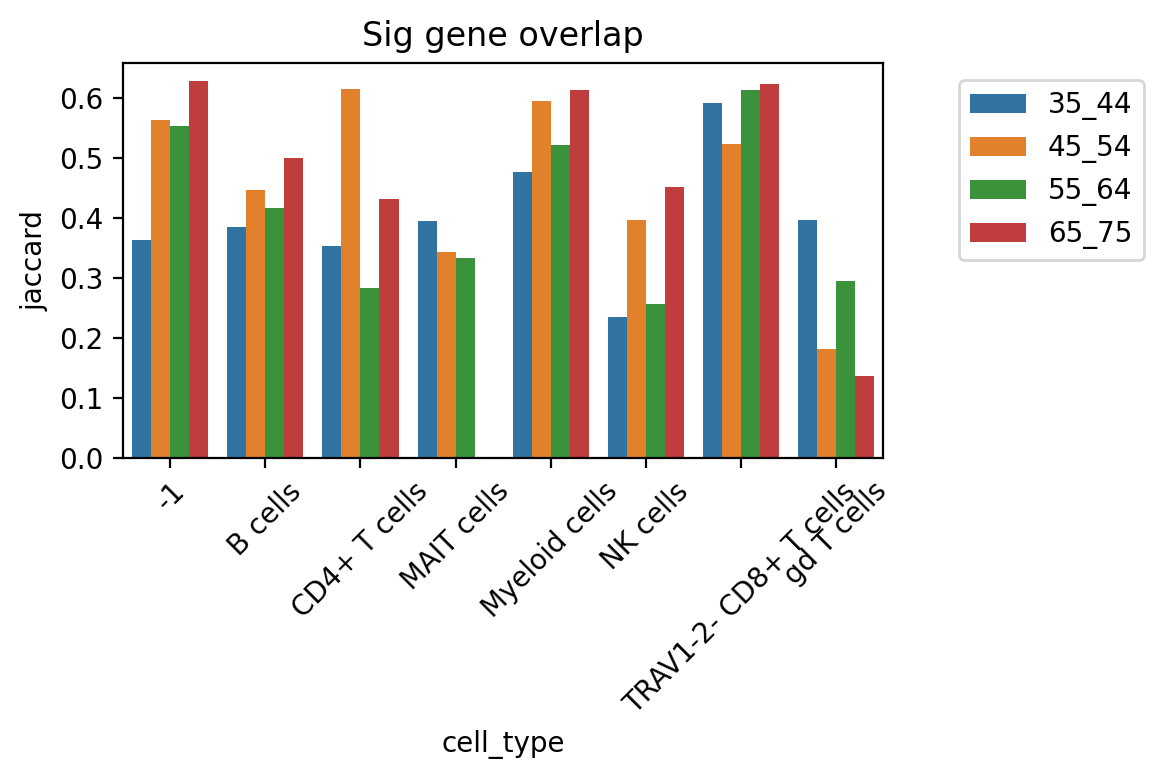

In [43]:
# - visualize overlapping genes 
results = []
for (cell_type, age_group), group in net_all_sig.groupby(['cell_type', 'age_group']):
    group1 = group[(group['batch_group'] == 'batch_1')][['g1', 'g2']].values.flatten()
    group2 = group[(group['batch_group'] == 'batch_2')][['g1', 'g2']].values.flatten()
    
    overlap = np.unique(np.intersect1d(group1, group2)).shape[0]
    total_group1 = len(group1)
    total_group2 = len(group2)
    total = total_group1+total_group2
    if total==0:
        overlap = 0
    else:
        jaccard = overlap/np.unique(np.union1d(group1, group2)).shape[0]

    
    results.append({
        'cell_type': cell_type,
        'age_group': age_group,
        'overlap': overlap,
        'jaccard':jaccard,
        'group1_count': total_group1,
        'group2_count': total_group2,
    })

# Create a results DataFrame
overlap_df = pd.DataFrame(results)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=overlap_df, 
    x='cell_type', 
    y='jaccard', 
    hue='age_group', 
    ci=None)
plt.legend(loc=(1.1, .5))
plt.xticks(rotation=45)
plt.title('Sig gene overlap')
plt.tight_layout()
plt.show()

## Qualitative comparitive analysis

### Pathways interactions using heatmap 

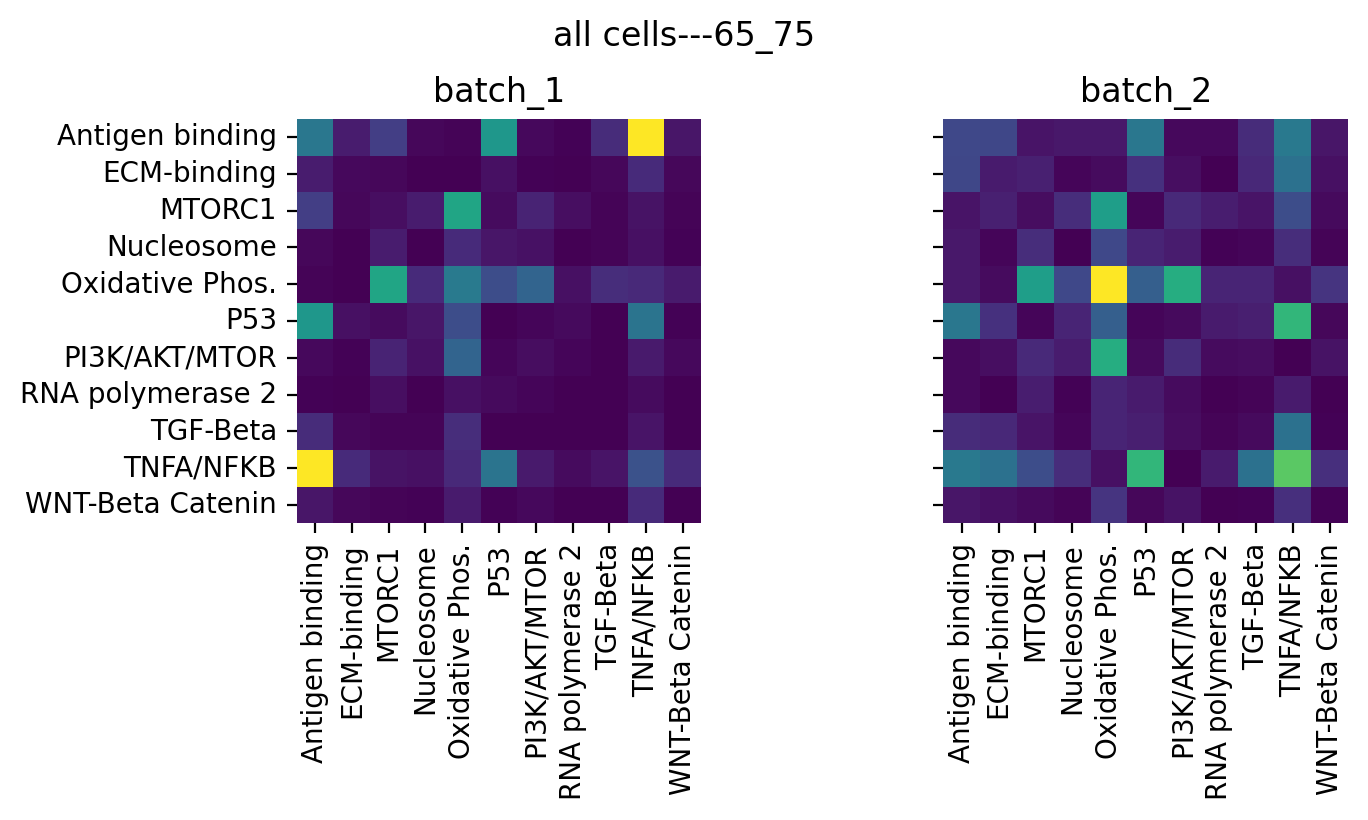

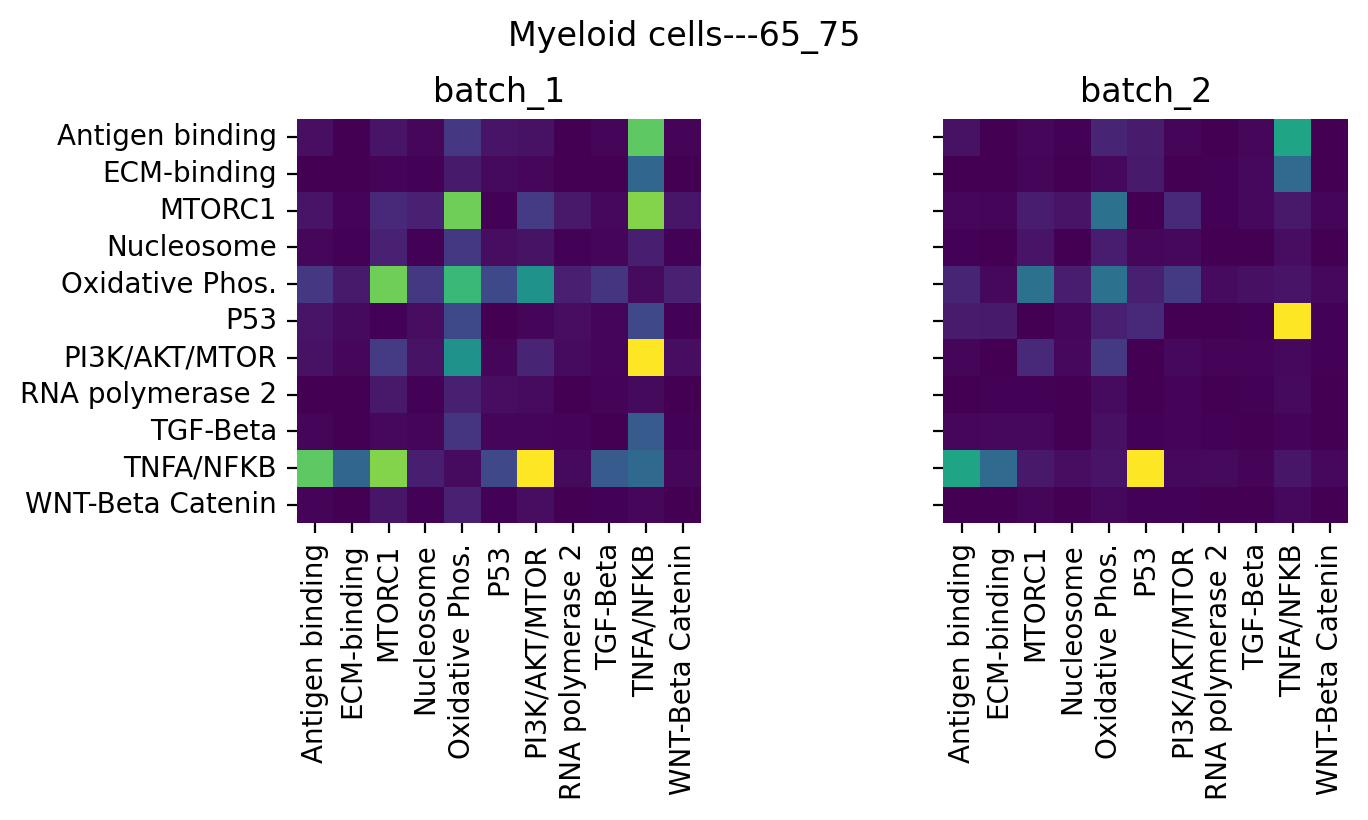

In [25]:
# - plot the interactions using heatmap 
if False:
    from src.helper import plot_pathway_interactions
    interaction_score_all = rr['interaction_score_all']
    i_run = 0
    for age_group in sorted(['65_75']):
        for cell_type in ['-1', 'Myeloid cells']:
            fig, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
            for i_batch, batch_group in enumerate(interaction_score_all['batch_group'].unique()):
                mask = (interaction_score_all['age_group'] == age_group) & (interaction_score_all['cell_type'] == cell_type) & (interaction_score_all['batch_group'] == batch_group)
                # mask = (interaction_score_all['batch_group'] == batch_group)
                pathway_interactions_df = interaction_score_all[mask]
                # print(f"age_group: {age_group}, cell_type: {cell_type}, batch_group: {batch_group}, rows: {len(pathway_interactions_df)}")

                # - plot the interaction
                ax=axes[i_batch]
                plot_pathway_interactions(pathway_interactions_df, ax=ax)
                ax.set_title(batch_group)
                if i_run == 0:
                    mask_ = mask.copy()
            if cell_type == '-1':
                cell_type = 'all cells'
            plt.suptitle(f'{cell_type}---{age_group}')
            plt.tight_layout()
            i_run+=1 

### Pathway interaction changes in for different cell types

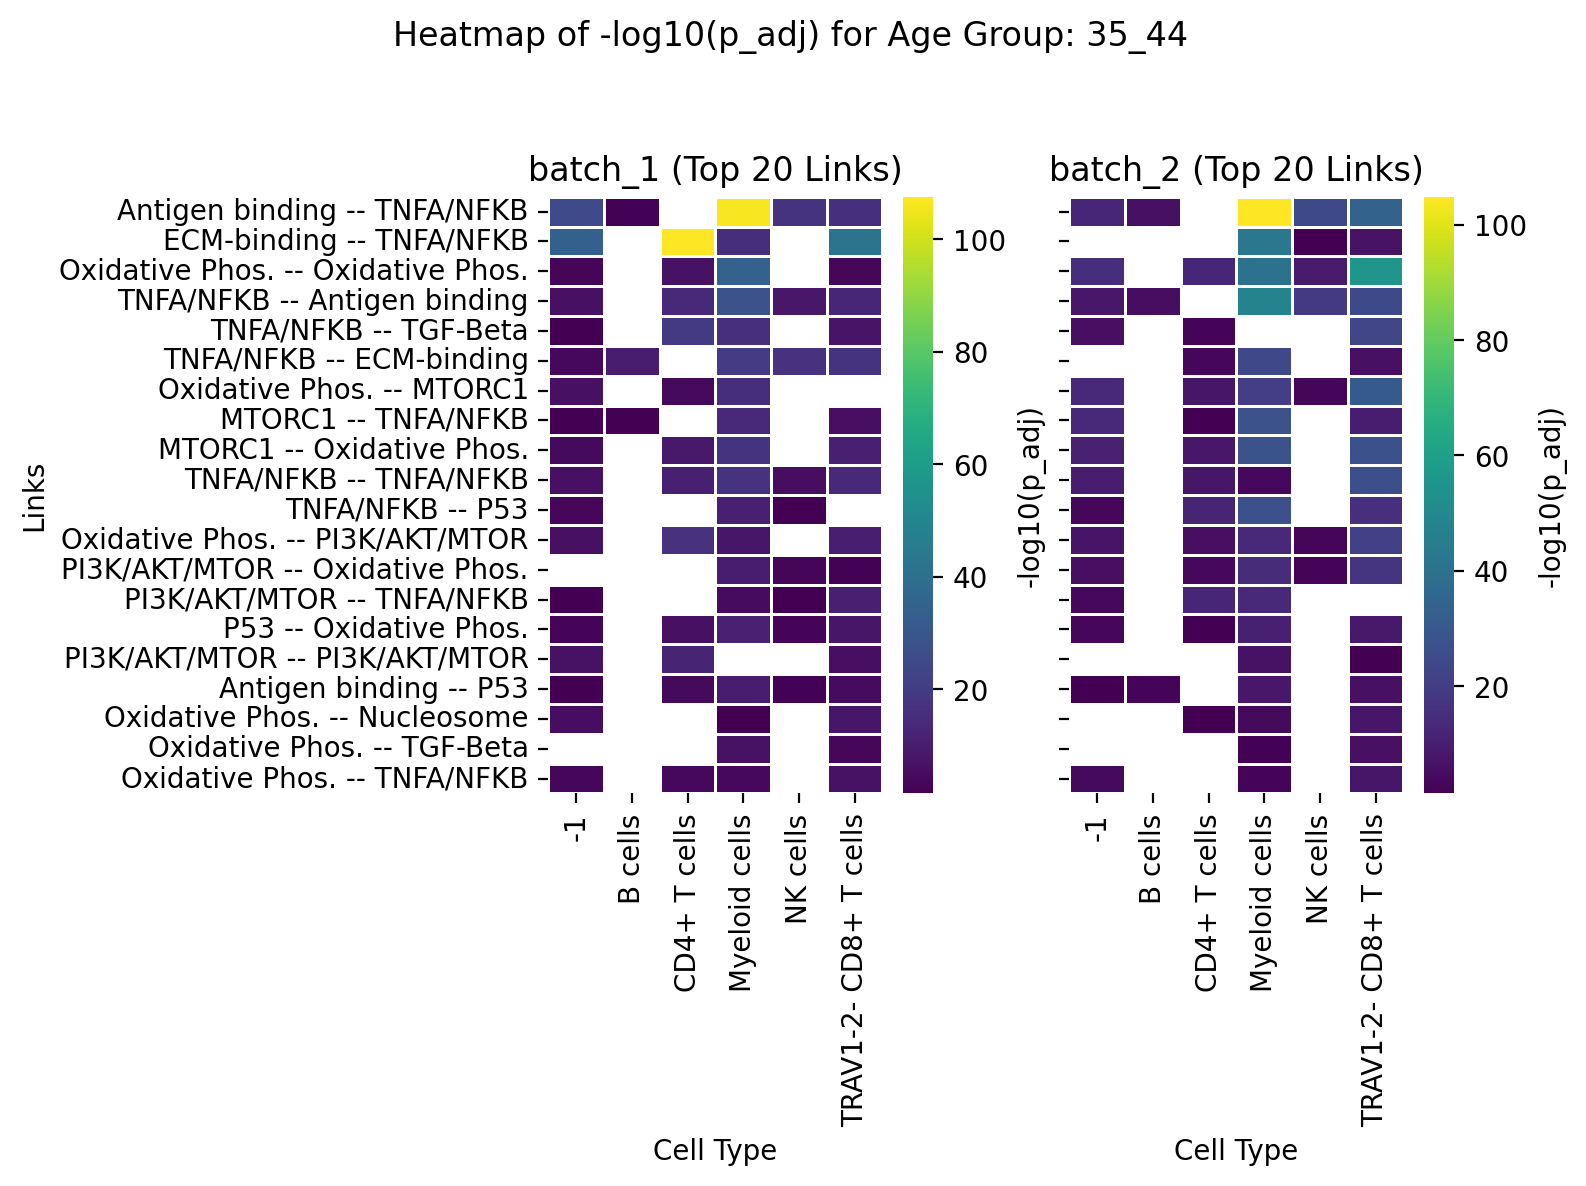

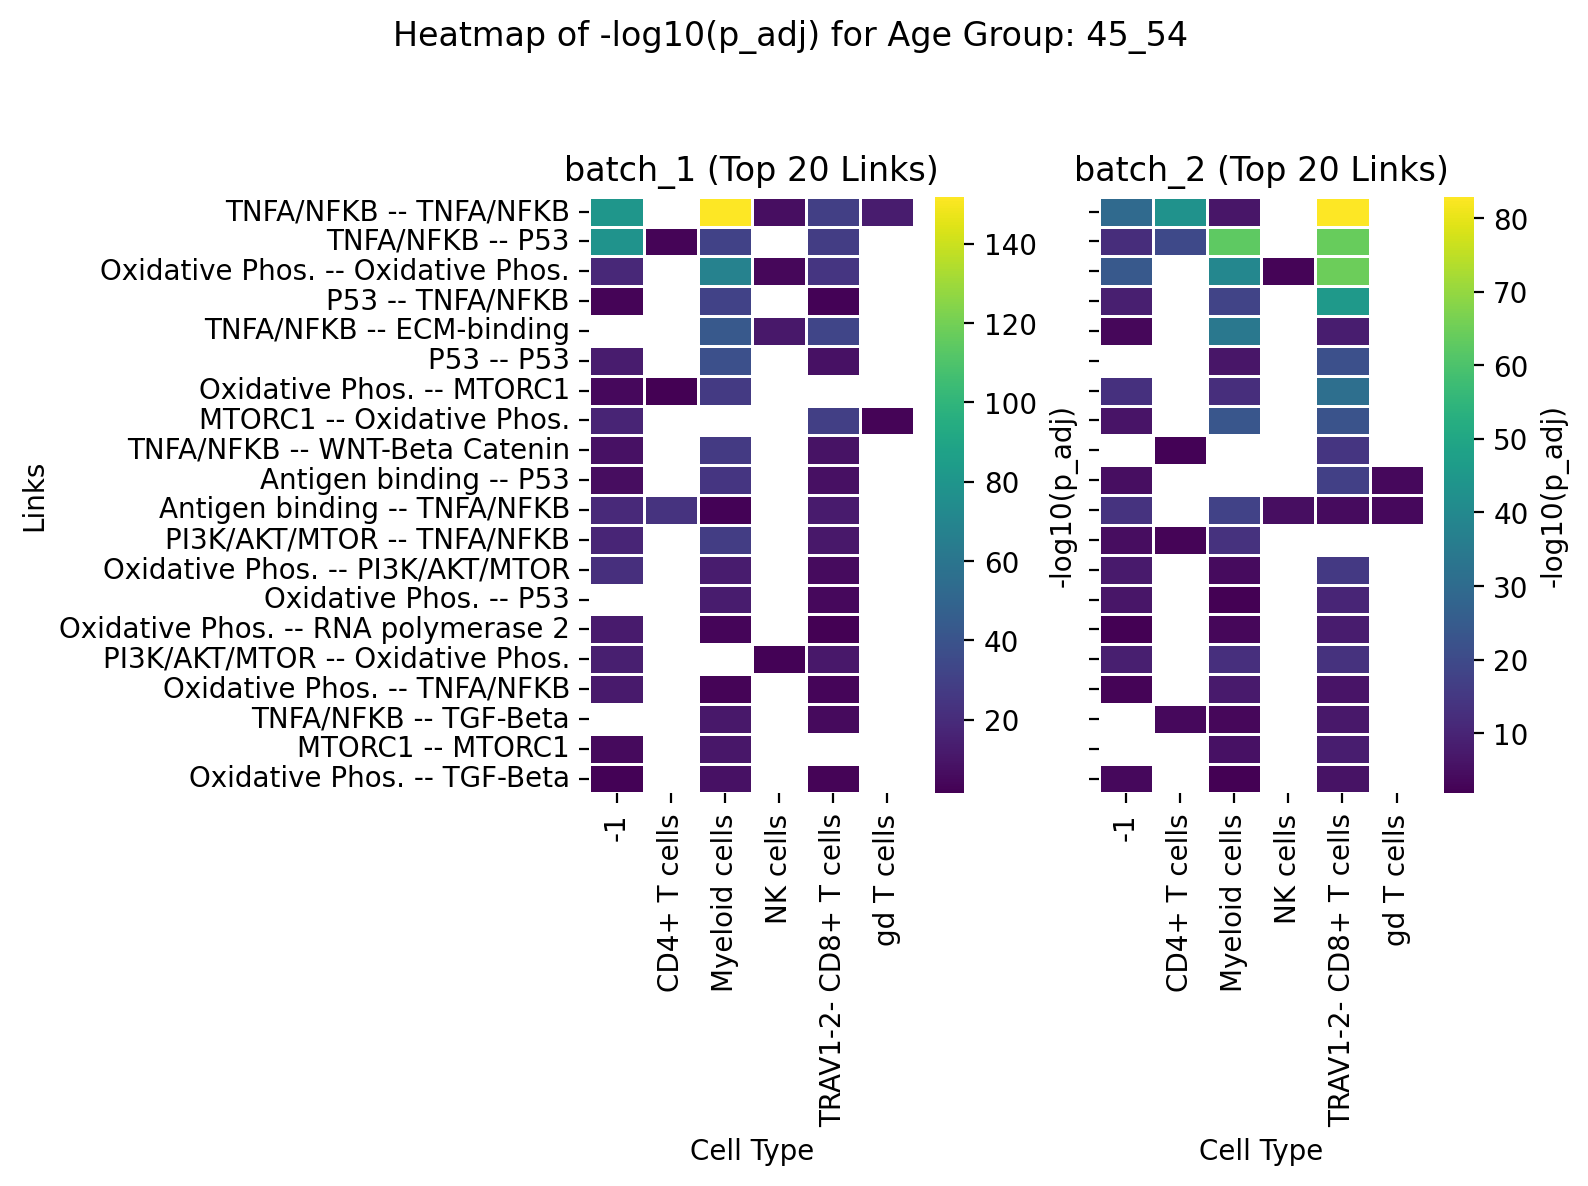

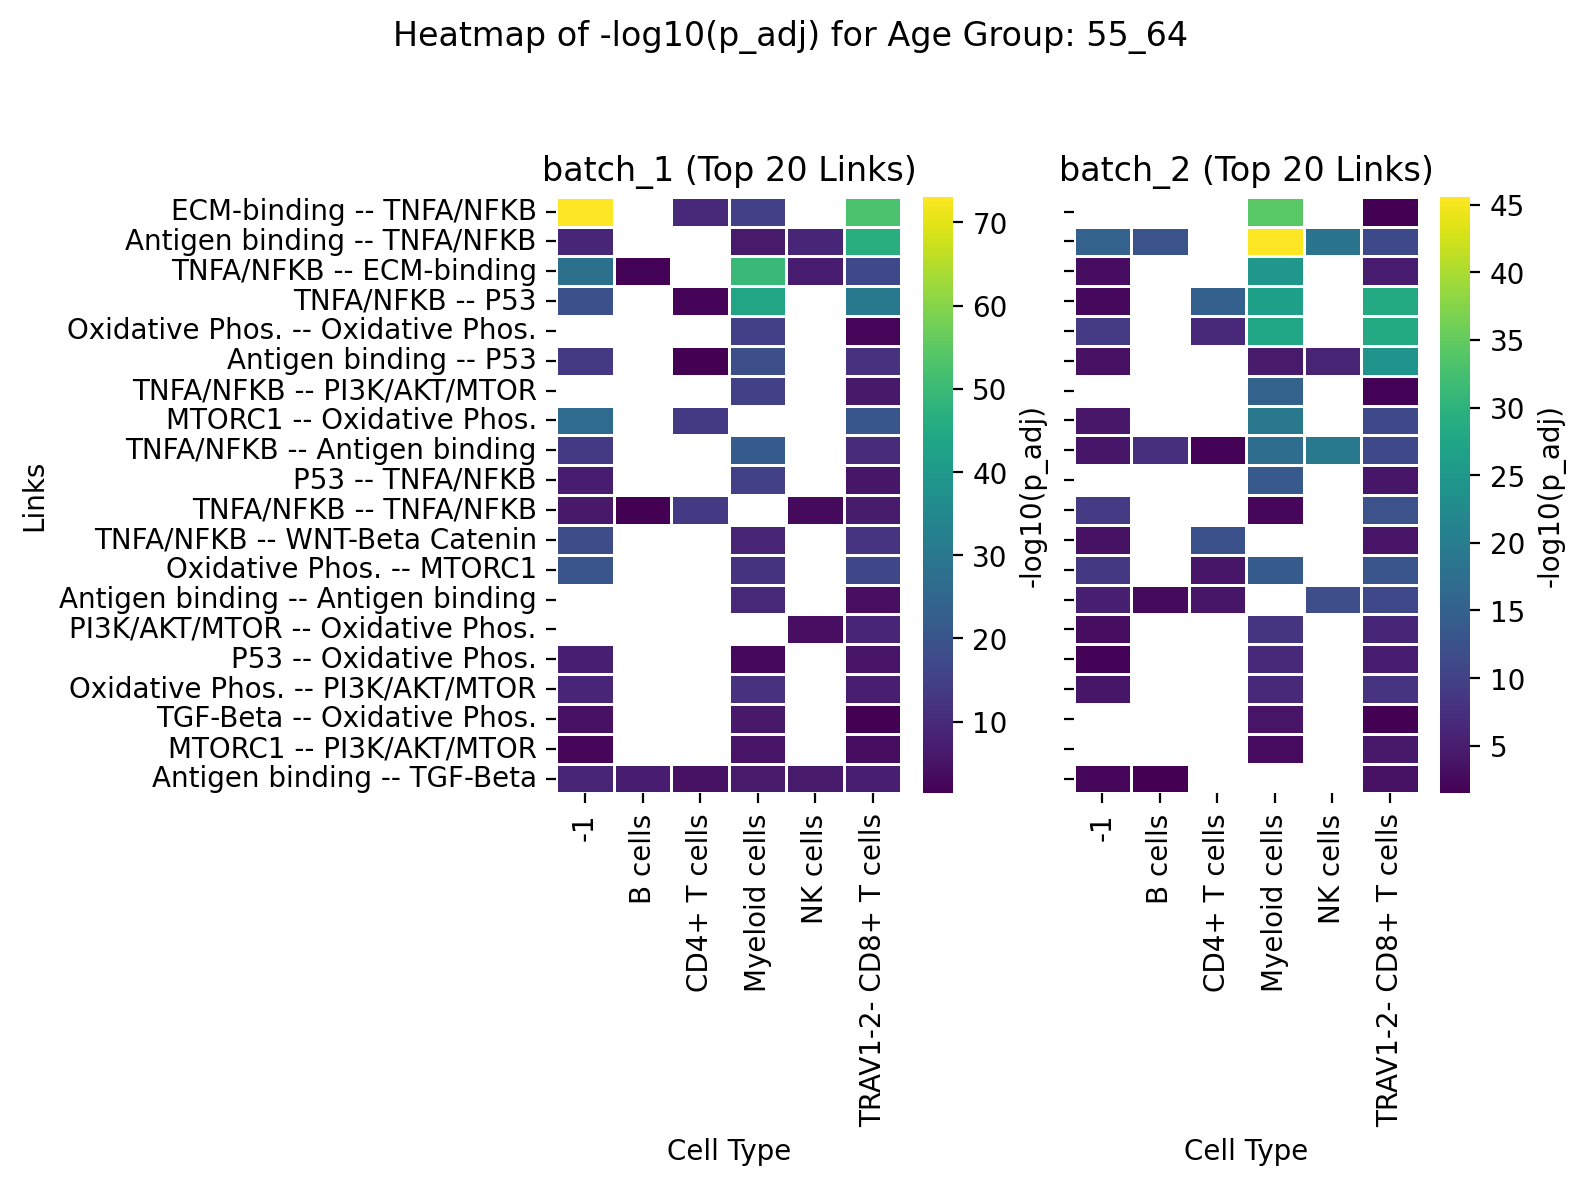

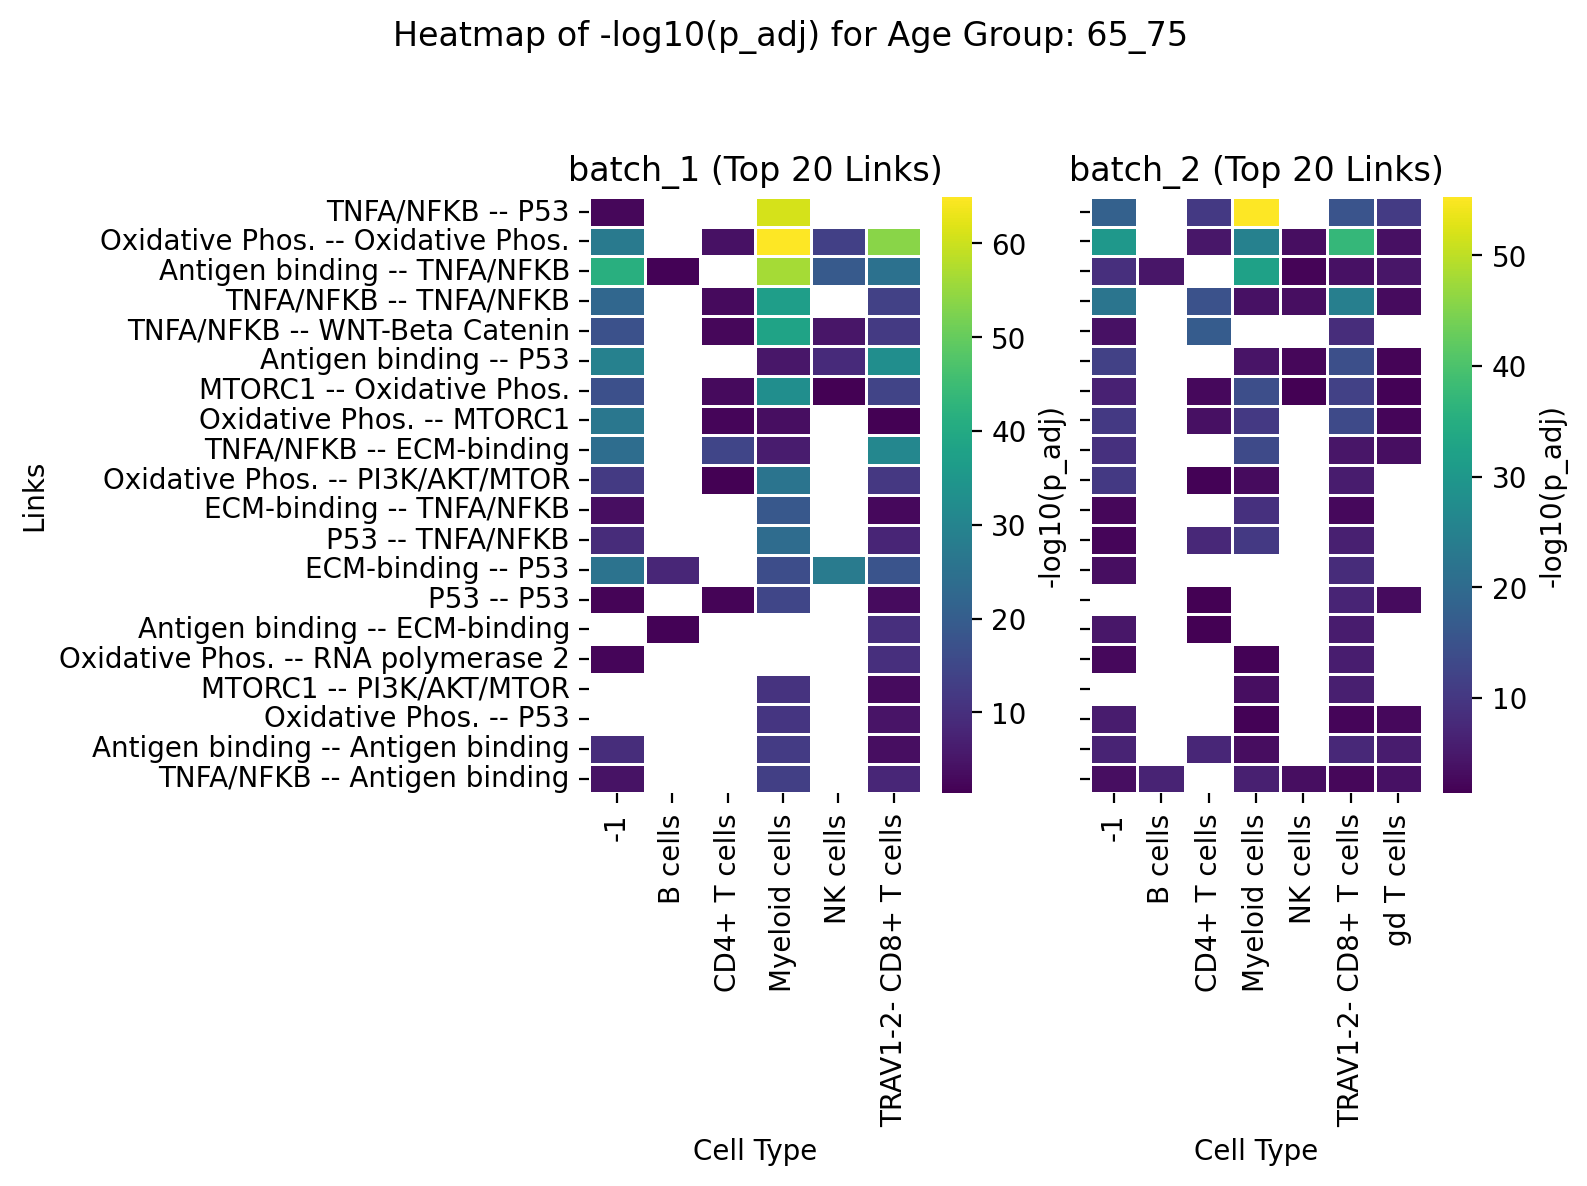

In [27]:
if True:
    from src.helper import plot_pathway_change_celltypes
    
    filtered_interaction_score_all = rr['filtered_interaction_score_all']
    for age_group in ['35_44','65_75']:
        # Filter data for the current age group
        plot_pathway_change_celltypes(filtered_interaction_score_all, age_group)
        
    plt.show()

### Joint distribution of pathway scores

In [12]:
# - joint plot of p-p interaction scores
if False:
    def plot_joint_diff_links(df_long, key1, key2, value='-log10_pvalue'):
        df_table = df_long.pivot(index='link', columns='batch_group', values=value)
        # print(df_table)


        mask_1 = df_table[key1]>6
        mask_2 = df_table[key2]>6

        # mask_na = ~df_table.isna()
        df_table['tag'] = 'Others'
        df_table.loc[mask_1 & mask_2, 'tag'] = df_table[mask_1 & mask_2].index


        sns.jointplot(
                data = df_table, 
                x = key1, 
                y = key2, 
                hue= 'tag',   # Color points by "True"/"False"
                # markers=True,
                # kind="kde",    # Contours with kde
                # fill=False,    # Fill contour lines
                # marginal_kws=dict(common_norm=False, fill=True),  # Marginal distribution,
                palette=sns.color_palette(),
                marginal_kws=None,
                alpha=.5,
                height=4,

            )
        plt.legend(loc=(1.3, 0))

    interaction_score_all = rr['interaction_score_all']
    for age_group in sorted(['65_75']):
        for cell_type in ['-1', 'Myeloid cells', 'TRAV1-2- CD8+ T cells']:
            pathway_interactions_df = interaction_score_all[(interaction_score_all['age_group'] == age_group) & (interaction_score_all['cell_type'] == cell_type)]

            plot_joint_diff_links(pathway_interactions_df, key1='batch_1', key2='batch_2')
            plt.suptitle(f'{age_group}-{cell_type} (-log10_pvalue)', y=1.1)

### Centrality changes in the course of time 

In [10]:
from src.helper_plots import plot_centrality_by_age
if False:
    centrality_df = rr['centrality_df']
    plot_centrality_by_age(cell_type='TRAV1-2- CD8+ T cells', centrality_df=centrality_df)


In [51]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/prior/tf_all.csv', dtype=str)
tf_all
# centrality_df['tf'] = centrality_df['gene'].isin(tf_all)

array(['ZNF354C', 'KLF12', 'ZNF143', ..., 'ZNF831', 'ZRSR2', 'ZSWIM1'],
      dtype='<U14')

### Joint centrality analysis

30
['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 's', 'o', 'o', 'o', 'o', 'o', 's', 's', 's', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 's', 'o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 's', 'o', 's', 's', 's', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'o', 'o', 'o', 'o', 'o', 's', 's', 's', 'o', 'o', 's', 's', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', '

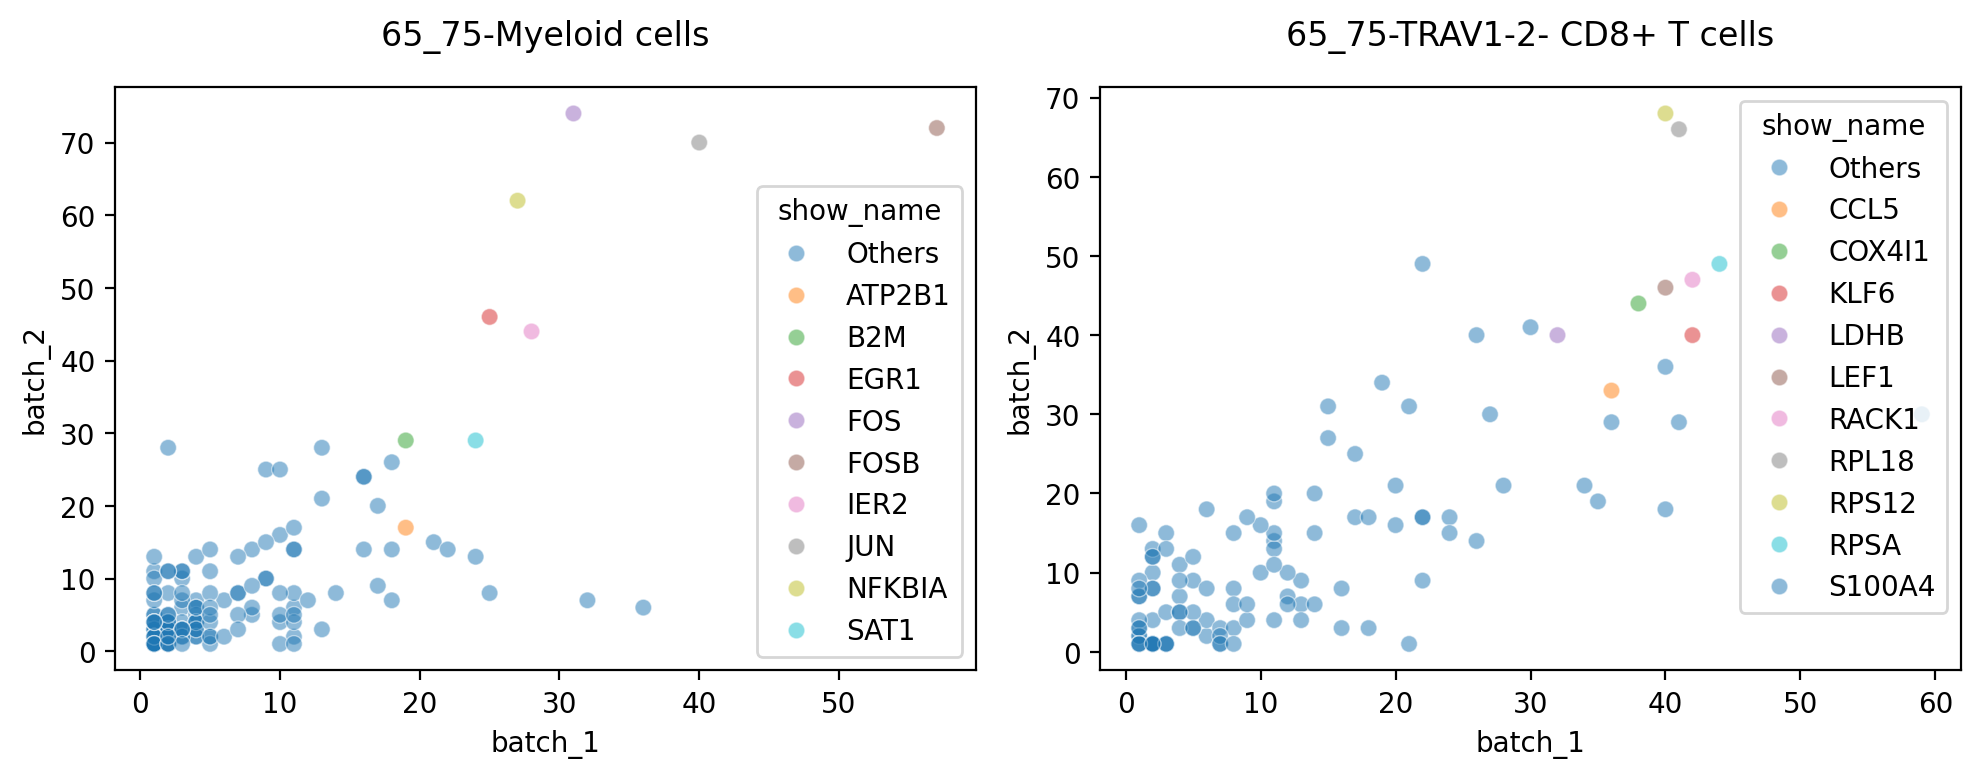

In [78]:
if True:
    def plot_joint_centrality(df_long, key1, key2, value='centrality', ax=None, mask_tf=True):
        df_table = df_long.pivot(index='gene', columns='batch_group', values=value)

        threshold_1 = df_table[key1].quantile(0.9)
        threshold_2 = df_table[key2].quantile(0.9)

        # Create masks based on the quantile thresholds
        mask_1 = df_table[key1] > threshold_1
        mask_2 = df_table[key2] > threshold_2


        # Assign tags
        tf_mask = df_table.index.isin(tf_all)
        print(tf_mask.sum())
        
        df_table['is_tf'] = tf_mask
        
        df_table['show_name'] = 'Others'
        mask_all = mask_1 & mask_2
        df_table.loc[mask_all, 'show_name'] = df_table.index[mask_all]

        print(['s' if tf else 'o' for tf in tf_mask])
        scatter = sns.scatterplot(
                data = df_table, 
                x = key1, 
                y = key2, 
                hue= 'show_name', 
                markers=['s' if tf else 'o' for tf in tf_mask],
                # markers={True: 's', False: 'o'},  
                # style='is_tf',
                palette=sns.color_palette(),
                alpha=.5,
                ax=ax

            )
        # tf_labels = ['TF', 'Non-TF']
        # tf_handles = [
        #     plt.Line2D([0], [0], marker='s', color='w', label='TF', markersize=8, markerfacecolor='k'),
        #     plt.Line2D([0], [0], marker='o', color='w', label='Non-TF', markersize=8, markerfacecolor='k'),
        # ]
        # tf_legend = ax.legend(handles=tf_handles, title="TF Status", loc="upper right", bbox_to_anchor=(1.3, 1))

        # # # Create hue legend for 'to_show'
        # handles, labels = ax.get_legend_handles_labels()
        # hue_legend = ax.legend(
        #     handles=handles[:len(df_table['show_name'].unique())], 
        #     labels=labels[:len(df_table['show_name'].unique())], 
        #     title="To Show", 
        #     loc="upper right", 
        #     bbox_to_anchor=(1.3, 0.6)
        # )

        # Add legends to plot
        # ax.add_artist(tf_legend)  # Add TF legend first
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    centrality_df = rr['centrality_df']
    ii = 0
    for age_group in sorted(['65_75']):
        for cell_type in ['Myeloid cells', 'TRAV1-2- CD8+ T cells']:
            centrality_df_sub = centrality_df[(centrality_df['age_group'] == age_group) & (centrality_df['cell_type'] == cell_type)]
            ax =  axes[ii]
            plot_joint_centrality(centrality_df_sub, key1='batch_1', key2='batch_2', ax=ax, mask_tf=False)
            ax.set_title(f'{age_group}-{cell_type}', pad=15)
            ii+=1
    plt.tight_layout()
    fig.savefig(f"{results_folder}/figs/diff_centrality_{age_group}.png", dpi=300, transparent=True, bbox_inches='tight')

    # fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # centrality_df = rr['centrality_df']
    # ii = 0
    # for age_group in sorted(['65_75']):
    #     for cell_type in ['Myeloid cells', 'TRAV1-2- CD8+ T cells']:
    #         centrality_df_sub = centrality_df[(centrality_df['age_group'] == age_group) & (centrality_df['cell_type'] == cell_type)]
    #         ax =  axes[ii]
    #         plot_joint_centrality(centrality_df_sub, key1='batch_1', key2='batch_2', ax=ax, mask_tf=True)
    #         ax.set_title(f'{age_group}-{cell_type}-tf masked', pad=15)
            
    #         ii+=1
    # plt.tight_layout()

## Quantitative comparision

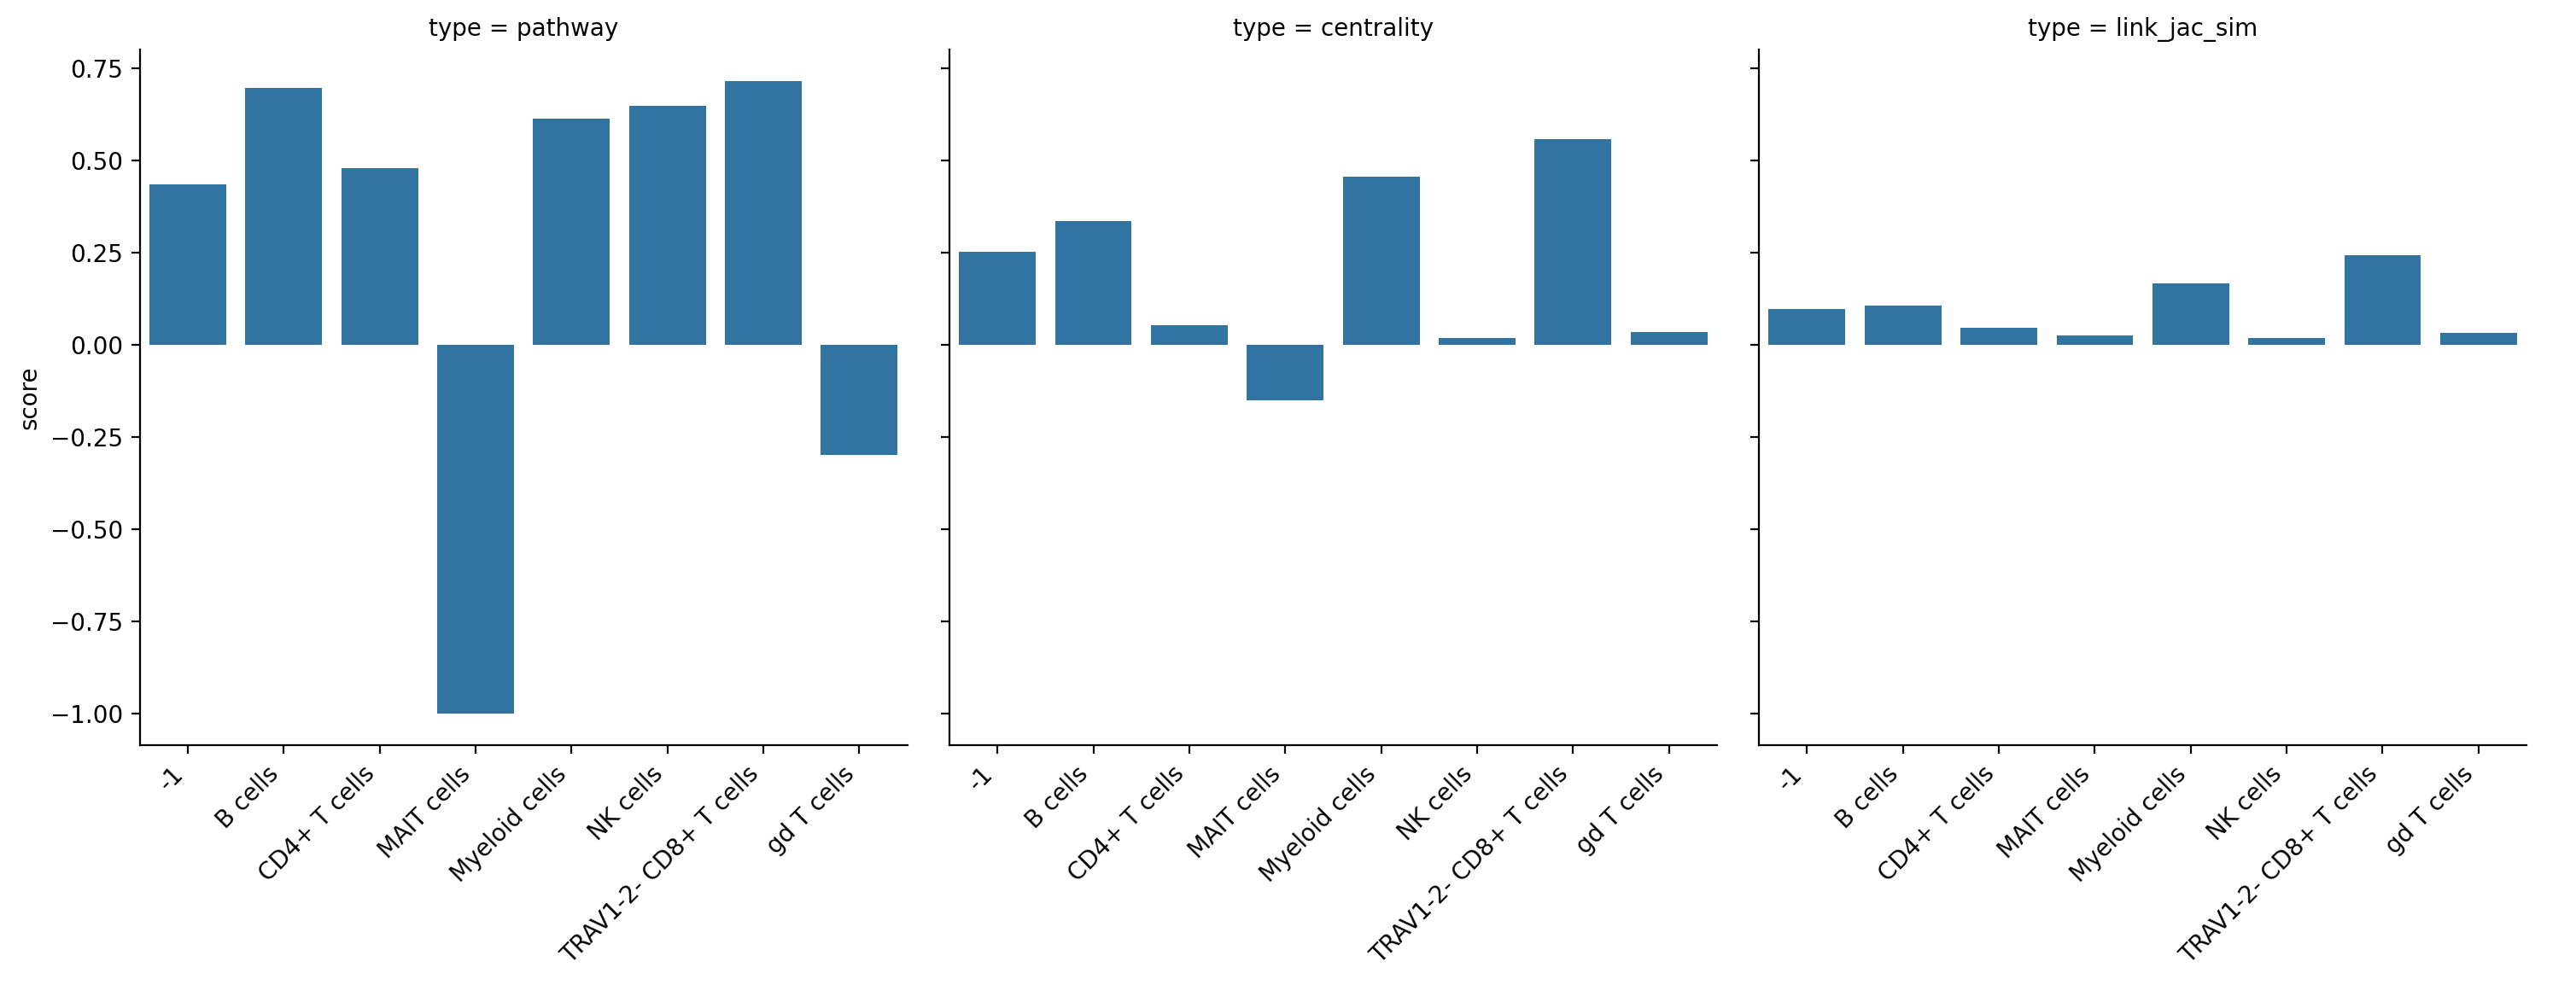

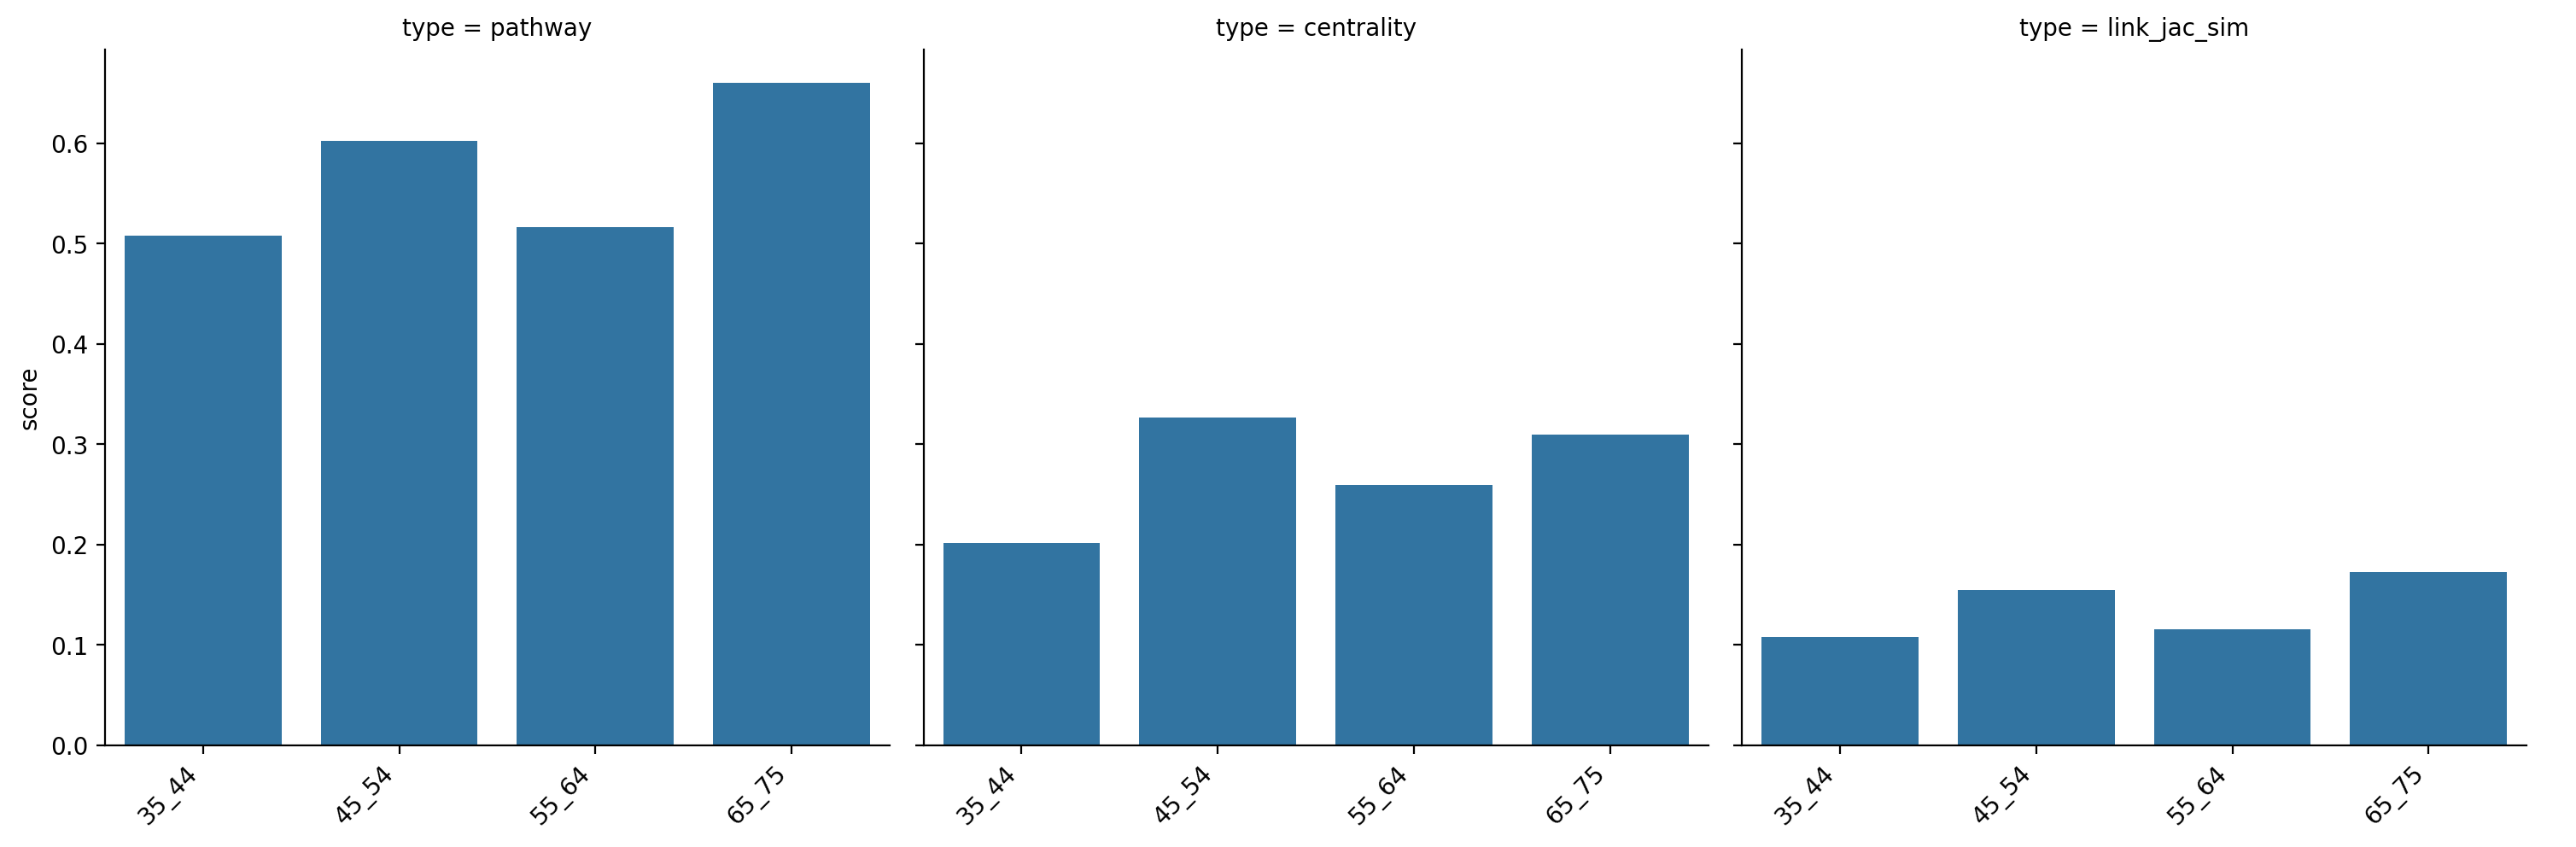

In [11]:
## Metric calculation calculation 
scores_all_dataset1 = rr['scores_all']
for seg in ['cell_type', 'age_group']:
    g = sns.catplot(scores_all_dataset1[~scores_all_dataset1[seg].isna()], x=seg, y='score', col='type', kind='bar')
    for ax in g.axes.flatten():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_xlabel('')

In [33]:
aa

NameError: name 'aa' is not defined

# Diff correlation: age donor dependent analysis

In [53]:
# - sig links across models
contrast_results_dict = {
    'sla_pearson_False': pd.read_csv('output/links_pvalues_vs_34_sla_pearson_False.csv', index_col=0),
    # 'sla_pearson_True': pd.read_csv('output/links_pvalues_vs_34_sla_pearson_True.csv', index_col=0),
    'sla_spearman_False': pd.read_csv('output/links_pvalues_vs_34_sla_spearman_False.csv', index_col=0),
    # 'sla_spearman_True': pd.read_csv('output/links_pvalues_vs_34_sla_spearman_True.csv', index_col=0),
}

i = 0
for key, df in contrast_results_dict.items():
    
    df['bonferroni'] = multipletests(df['pvalue'], alpha=0.05, method='bonferroni')[1]
    df['fdr'] = multipletests(df['pvalue'], alpha=0.05, method='fdr_bh')[1]
    
    # - add sig column
    df['sig'] = df['fdr']<0.05

    # - filter low rank links
    df = df[df['fdr']<0.05]

    df['model'] = key
    if i == 0:
        sig_results = df
    else:
        sig_results = pd.concat([df, sig_results], axis=0)
    i+=1
sig_results

,link,age_group,pvalue,mean,median,mean_ctr,mean_median,diff_median,diff,bonferroni,fdr,sig,model
21,LCK_RHOB,55_64,0.004178,-0.166678,-0.163619,-0.193380,-0.190048,0.026429,0.026702,1.000000,0.039693,True,sla_spearman_False
22,LCK_RHOB,45_54,0.003043,-0.166975,-0.157858,-0.193380,-0.190048,0.032190,0.026406,1.000000,0.032936,True,sla_spearman_False
25,IL7R_LCK,55_64,0.005294,0.168395,0.171846,0.208100,0.200408,-0.028562,-0.039705,1.000000,0.045530,True,sla_spearman_False
29,CD83_LCK,55_64,0.004656,-0.246812,-0.248452,-0.285189,-0.291517,0.043065,0.038377,1.000000,0.042247,True,sla_spearman_False
30,CD83_LCK,45_54,0.000442,-0.241045,-0.232407,-0.285189,-0.291517,0.059110,0.044144,1.000000,0.012099,True,sla_spearman_False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8101,PRMT2_SAT1,55_64,0.000073,-0.147015,-0.140930,-0.190681,-0.198423,0.057493,0.043667,0.590314,0.004723,True,sla_pearson_False
8102,PRMT2_SAT1,45_54,0.000893,-0.155649,-0.140617,-0.190681,-0.198423,0.057805,0.035032,1.000000,0.014987,True,sla_pearson_False
8112,CFP_SAT1,65_75,0.001855,0.458763,0.461702,0.426863,0.433659,0.028043,0.031900,1.000000,0.021312,True,sla_pearson_False
8116,IL2RG_SAT1,65_75,0.004270,-0.375405,-0.390208,-0.325962,-0.324645,-0.065563,-0.049443,1.000000,0.032851,True,sla_pearson_False


In [59]:
# - common sig links across different methods
n_methods = sig_results.model.nunique()
df = (sig_results.groupby(['link', 'age_group']).apply(lambda df: df['sig'].sum())==n_methods).reset_index(name='sig_common')
sig_results = sig_results.merge(df, on=['link', 'age_group'], how='left')
common_links_df = sig_results[sig_results['sig_common']]

# - add data of each method in the format of method-tag and mean across all
def merge_cols(df):
    # take mean corr
    # df_mean = df.groupby(['link', 'age_group'])['mean'].mean().reset_index(name='mean')
    # pivot to get model specific columns
    df_pivot = df.pivot_table(
        index=['link', 'age_group'],  
        columns='model',              
        values=['mean', 'mean_ctr', 'diff'] 
    )
    df_pivot.columns = ['{}-{}'.format(model, item) for item, model in df_pivot.columns]
    # merge mean with model specific info
    df_pivot = df_pivot.reset_index()
    # df_pivot = df_pivot.merge(df_mean, on=['link', 'age_group'])

    return  df_pivot

common_links_df = merge_cols(common_links_df)

# - add mean corr across all methods
cols_mean = [f'{method}-mean' for method in contrast_results_dict.keys()]
common_links_df['mean'] = common_links_df[cols_mean].mean(axis=1)
common_links_df

,link,age_group,sla_pearson_False-diff,sla_spearman_False-diff,sla_pearson_False-mean,sla_spearman_False-mean,sla_pearson_False-mean_ctr,sla_spearman_False-mean_ctr,mean
0,ACTB_ALDOA,65_75,0.029076,0.031500,0.152737,0.154625,0.123661,0.123125,0.153681
1,ACTB_CASP1,35_44,0.021268,0.024681,0.131056,0.153887,0.109788,0.129207,0.142472
2,ACTB_CFL1,55_64,-0.028325,-0.027399,0.299079,0.306604,0.327405,0.334003,0.302841
3,ACTB_CXCR4,65_75,-0.039766,-0.037423,-0.202407,-0.209667,-0.162641,-0.172244,-0.206037
4,ACTB_LEF1,55_64,0.029858,0.027994,-0.207104,-0.214694,-0.236962,-0.242688,-0.210899
...,...,...,...,...,...,...,...,...,...
827,SPON2_STOM,55_64,-0.041113,-0.036707,0.206568,0.203430,0.247681,0.240138,0.204999
828,SPON2_SYTL2,45_54,-0.020896,-0.023748,0.150298,0.157659,0.171194,0.181407,0.153979
829,TCF7_UQCRB,45_54,-0.024951,-0.028157,0.166524,0.171350,0.191475,0.199507,0.168937
830,TCF7_UQCRB,55_64,-0.038812,-0.040289,0.152663,0.159218,0.191475,0.199507,0.155940


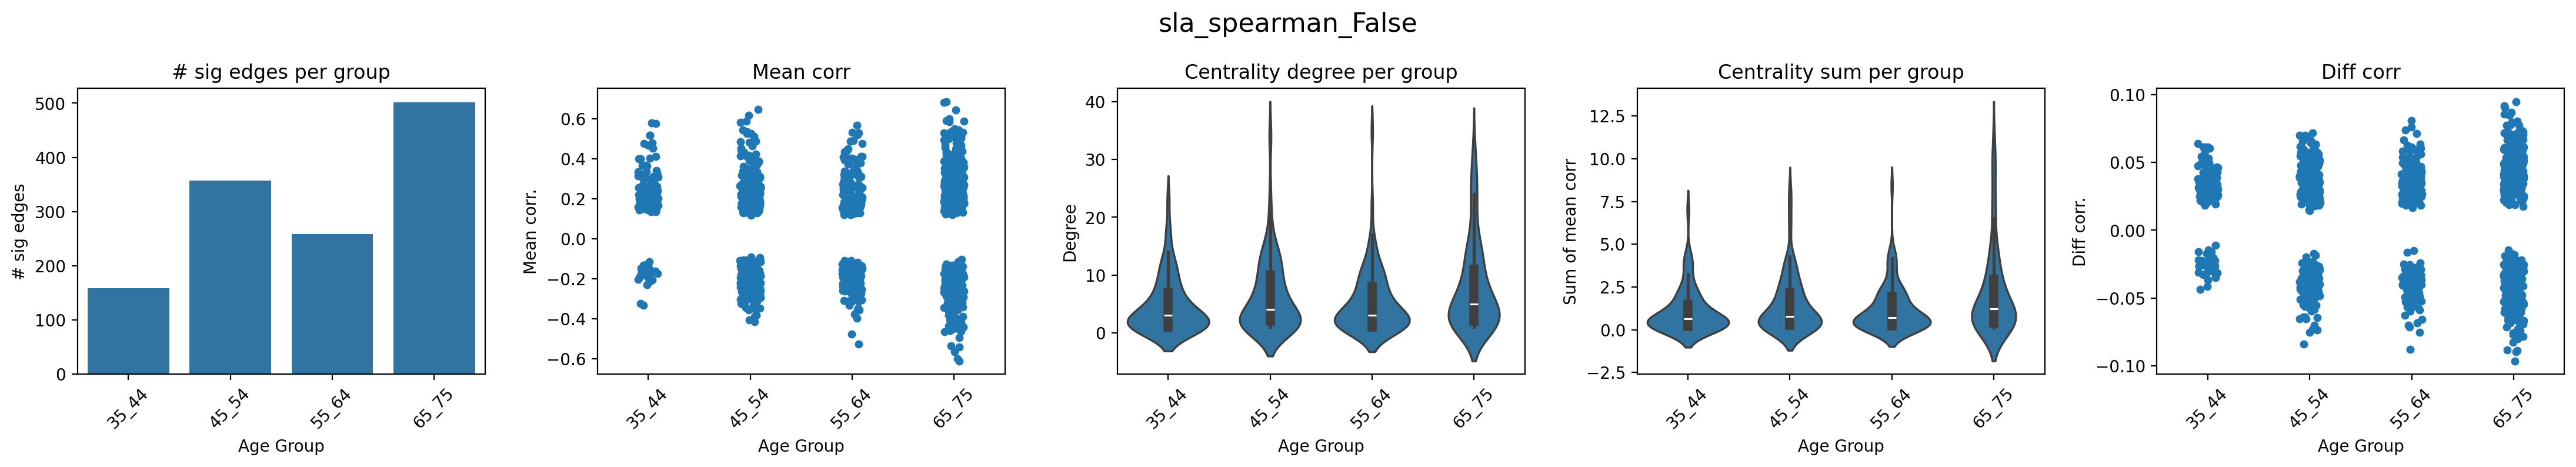

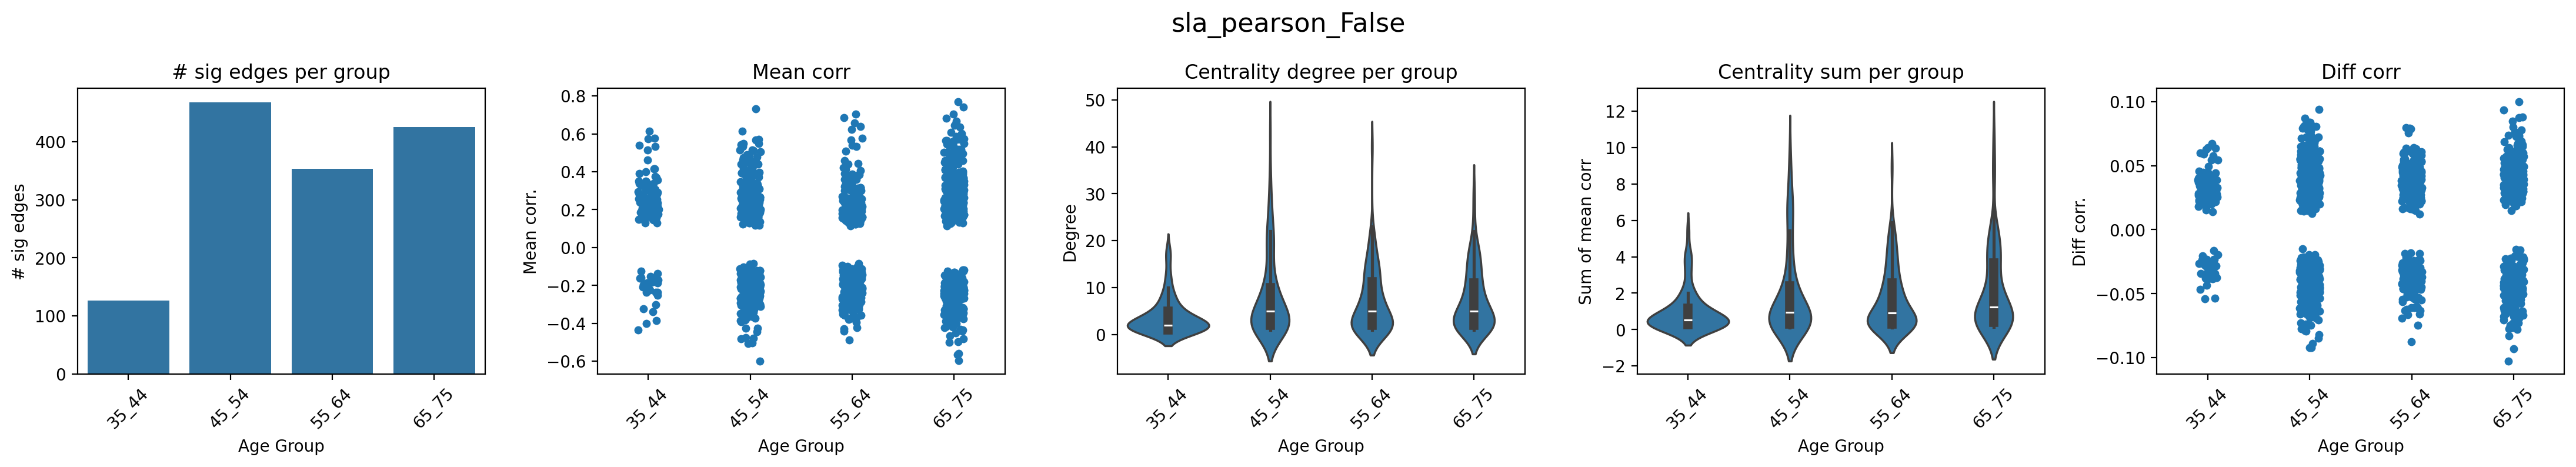

In [61]:
# - plot dist of number of sig links

for model in sig_results.model.unique():
    df = sig_results[sig_results.model==model]
    groups = df.groupby('age_group')
    plot_exp(groups, model)
    

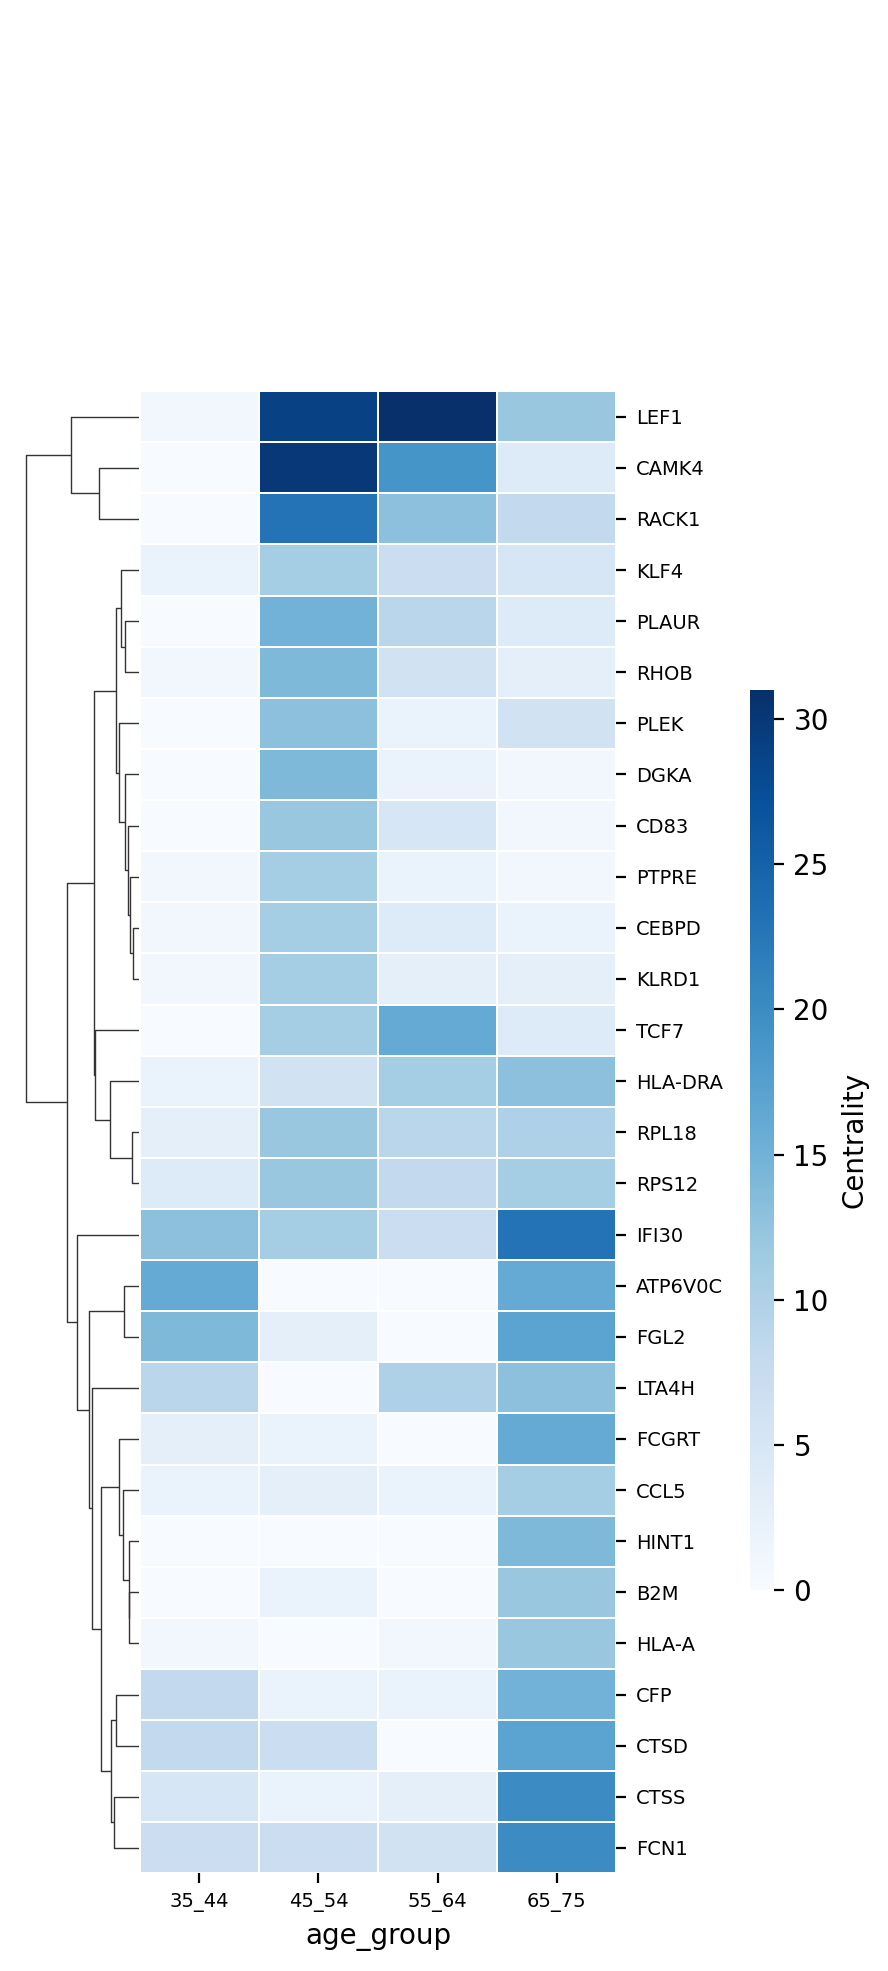

In [74]:
# - centrality degree dotplot, all ages, genes with degree > 10 in the target groups

if True: # plot_centrality_cluster()
    degree_t = 10

    groups = common_links_df.groupby('age_group')
    figsize=(4,10)
    target_groups=['45_54','65_75']

    # - heatmap
    def link_to_centrality(df):
        df['weight'] = 1
        gg_mat = link_to_matrix(df)
        degree = gg_mat.sum(axis=1)  
        return degree
    centrality_df = groups.apply(link_to_centrality).reset_index(level=0, name='degree').pivot(columns='age_group', values='degree').fillna(0)

    # filter 
    centrality_df = centrality_df[(centrality_df>degree_t)[target_groups].any(axis=1)]

    # plot
    g = sns.clustermap(centrality_df, cmap="Blues", row_cluster=True, col_cluster=False, 
                    figsize=figsize, linewidths=0.01, xticklabels=True, yticklabels=True, 
                    cbar_pos=(0.95, 0.2, 0.03, 0.45))
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=7)  
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7)  
    g.cax.set_ylabel('Centrality')
    plt.tight_layout()

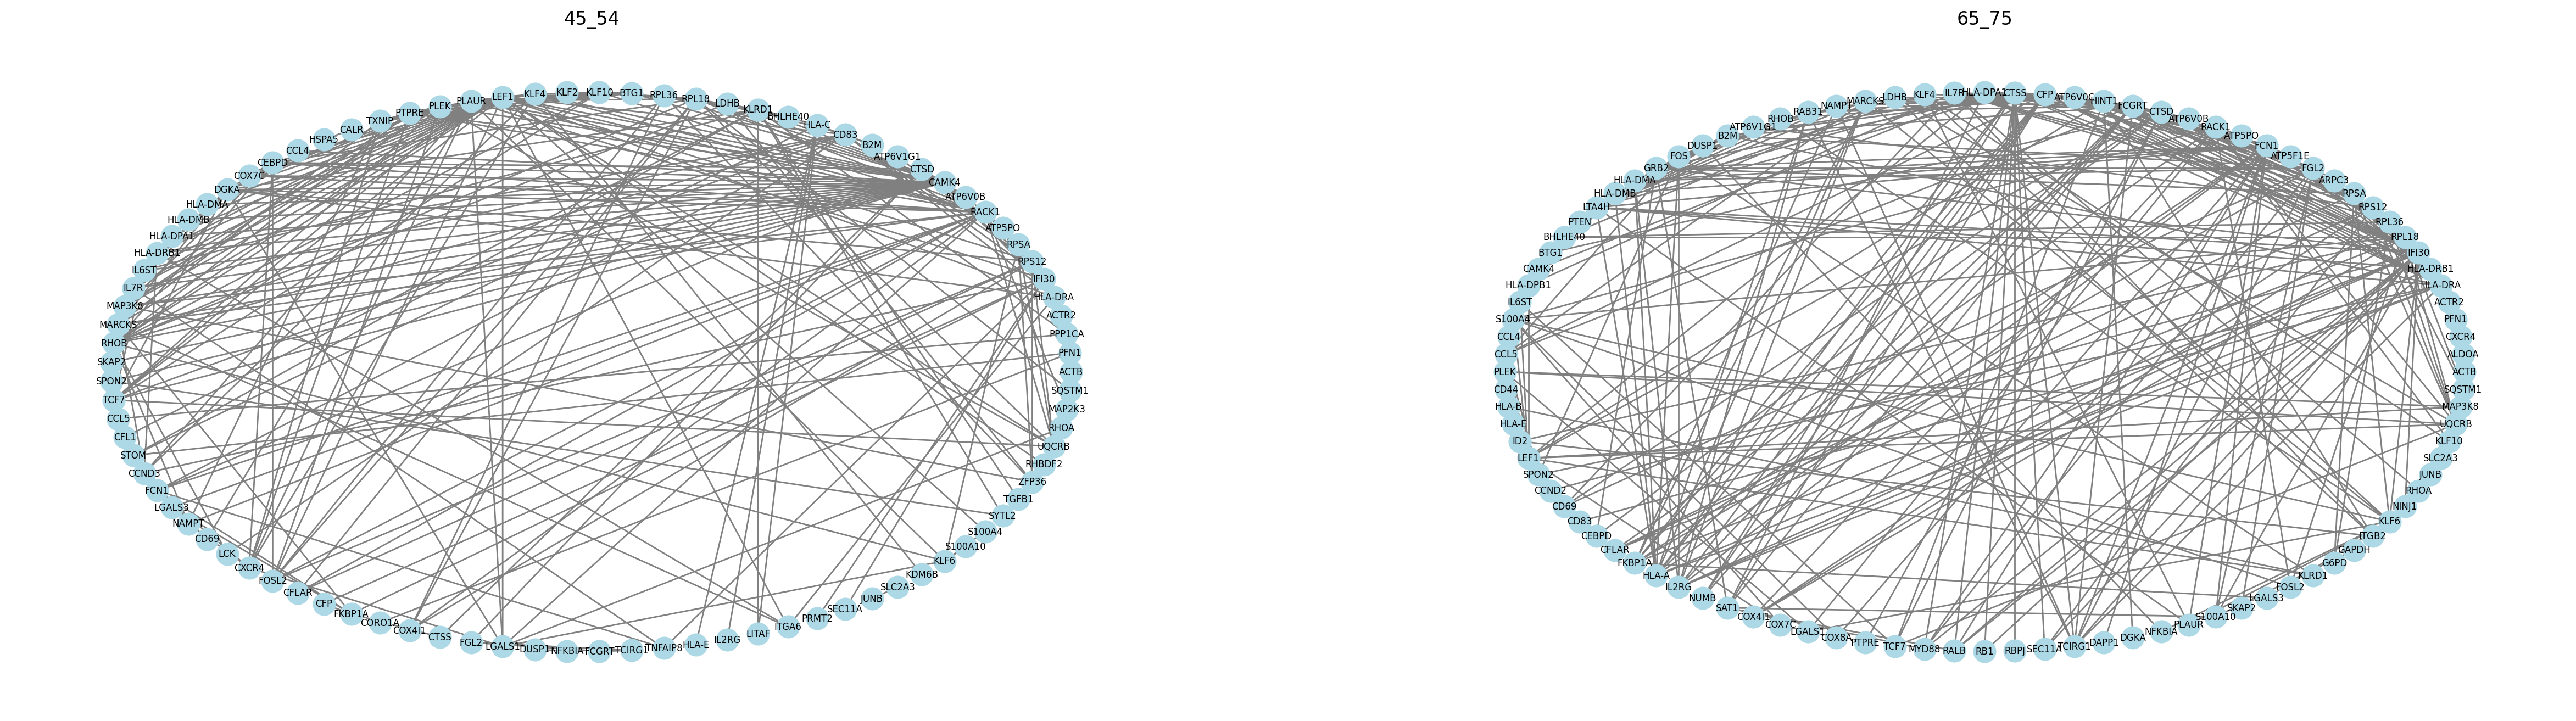

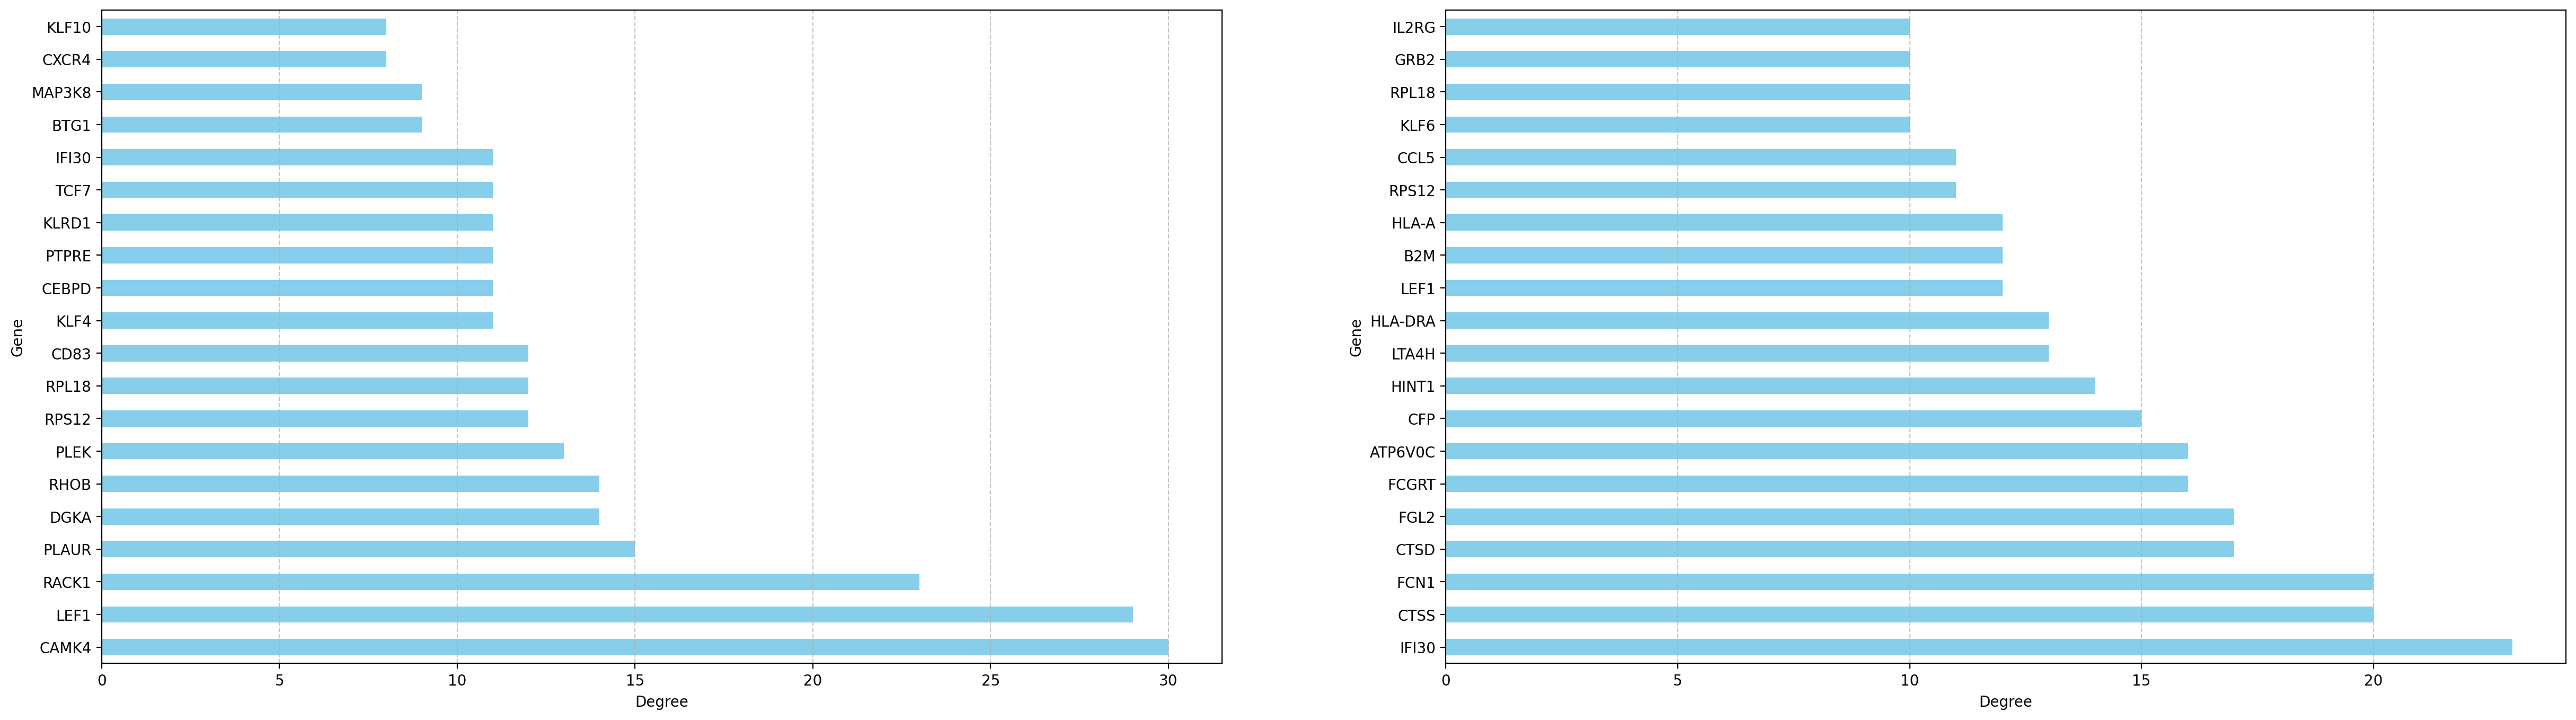

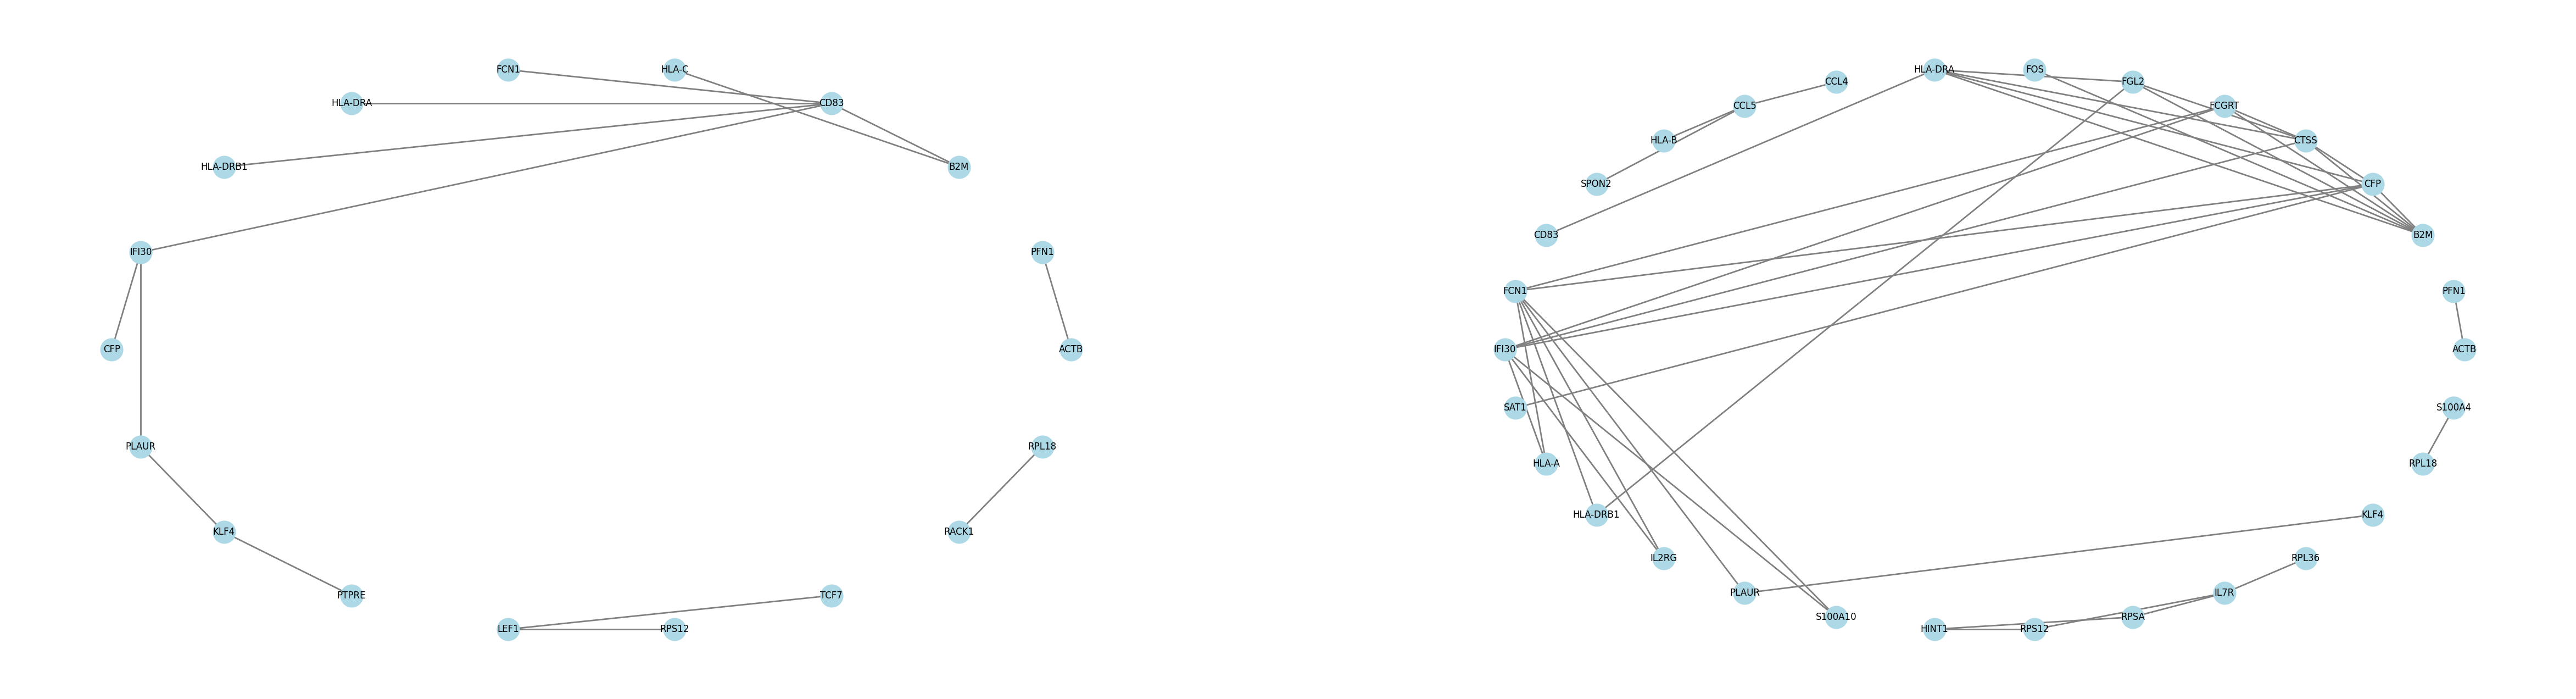

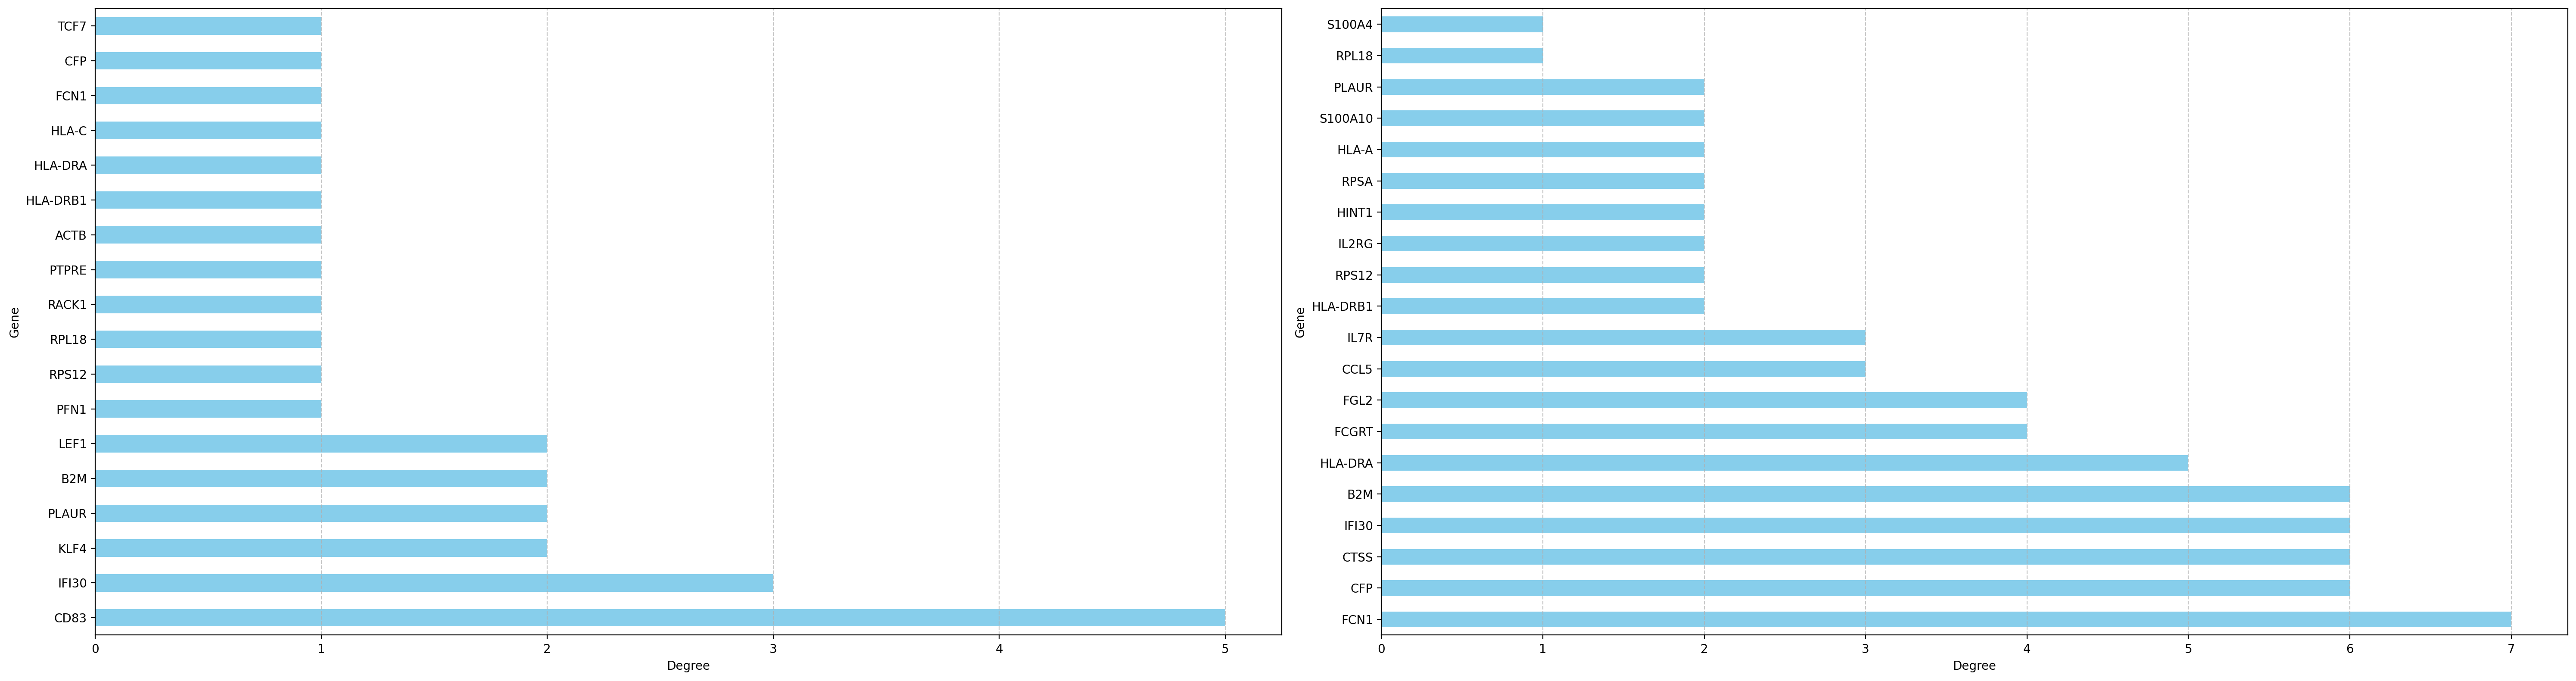

In [83]:
if True: # age group specific G plots and top degree fo 
    groups = common_links_df.groupby('age_group')
    age_groups_to_show =  ['45_54', '65_75']

    _, axes = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes_ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes__ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))
    _, axes___ = plt.subplots(1, len(age_groups_to_show), figsize=(15*len(age_groups_to_show), 8))

    i_plot = 0 
    for age_group in age_groups_to_show:
        try:
            ax = axes[i_plot]
        except:
            ax = axes
        if age_group == '34-':
            continue
        # - plot all edges in G plot
        links_a = groups.get_group(age_group)
        G_plot(links_a, ax=axes[i_plot])
        ax.set_title(f'{age_group}') 

        # # - plot centrality
        links_a['weight'] = 1
        gg_mat = link_to_matrix(links_a)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes_[i_plot])

        # - shortlist edges in G plot based on corr weights
        links_a_short = links_a[links_a['mean'].abs()>0.4]
        if len(links_a_short)<2: 
            continue
        G_plot(links_a_short, ax=axes__[i_plot])
        ax.set_title(f'{age_group}') 

        # - plot centrality for shortlist
        links_a_short['weight'] = 1
        gg_mat = link_to_matrix(links_a_short)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes___[i_plot])

        i_plot+=1

        plt.tight_layout()